## Imports

In [338]:
import warnings
warnings.filterwarnings("ignore")

In [339]:
import math
import os
import time
import requests
import pandas as pd
import json
import numpy as np
from pathlib import Path
from typing import Optional, Dict, List, Union
from unidecode import unidecode
import matplotlib.pyplot as plt

import pandas_gbq
from google.auth import default
from google.cloud import bigquery
from google.api_core.exceptions import NotFound

from IPython.display import display

In [340]:
from funcoes_escoragem import *
from funcoes_monitoramento import *

## Diretório

In [341]:
BASE_DIR = Path("data")
RAW_DIR = BASE_DIR / "raw"
TRUSTED_DIR = BASE_DIR / "trusted"
ANALYTICS_DIR = BASE_DIR / "analytics"

for path in [RAW_DIR, TRUSTED_DIR, ANALYTICS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

## Performance

In [342]:
project_id = 'loft-dl-fintech'

In [ ]:
project_id = 'loft-dl-datascience'

query = '''
WITH
first_defaults AS (
  SELECT
    contract_id,
    DATE(MIN(pendency_created_at)) AS first_comunicacao_date,
    DATE(MIN(pendency_at)) AS first_competencia_date,
    DATE(MIN(payment_at)) AS first_payment_date
  FROM `loft-dl-fintech.cp_gold.watchlist_fact`
  WHERE pendency_type IN ('Inadimplência')
  GROUP BY contract_id
),

tb_leads as(
  SELECT
    rf.contract_id,
    date(cf.requested_at) as requested_at,
    cf.tipo,
    cf.tipo_contrato,
    cf.rule,
    cf.bureau_nm,
    cf.modeloBlend,
    rf.approved_products,
    case when '32' in unnest(json_value_array(rf.approved_products)) then 1 else 0 end as flag_pop32,
    rd.product_nm,
    case when cf.modeloBlend = 'BLEND_REGRESSAO_2026' and cf.bureau_nm in ('BLEND_REGRESSAO_2026', 'BVS_CUSTOM', 'HVA3') then 'BLEND2'
        when cf.modeloBlend in ('BLEND3_3', 'BLEND3_4') and cf.bureau_nm in ('BLEND3_3', 'BLEND3_4', 'BVS_CUSTOM', 'HVA4') then 'BLEND3'
        when cf.modeloBlend in ('BLEND_4', 'BVS_CUSTOM_V2', 'HFT1') and cf.bureau_nm in ('BLEND_4', 'BVS_CUSTOM_V2', 'HFT1') then 'BLEND4'
        else 'Outros' end as bureau_nm_ajust,
    case when cf.modeloBlend in ('BLEND3_3', 'BLEND3_4') and cf.bureau_nm in ('BVS_CUSTOM', 'HVA4') then 1
        when cf.bureau_nm in ('BVS_CUSTOM_V2', 'HFT1') then 1
        else 0 end as is_fallback, -- apenas blend3 e blend4
    i.id_imobiliaria,
    i.id_cidade_ibge,
    i.cidade as imovel_cidade,
    i.uf as imovel_uf,
    ad.segmentacao as agency_segmentacao,
    rd.lead_elegivel,
    rd.proposta_iniciada,
    rd.proposta_enviada,
    rd.proposta_aprovada,
    rd.proposta_ativada,
    rd.is_activeted,
    rf.activated_at,
    rd.aprovado_motor_mesa,
    coalesce(cf.rating_score_ds, '-1') as rating_score_ds,
    case when coalesce(cf.qtd_proponentes, -1) <= 1 then 1 else 0 end as is_single_proponent,
    ca.blend_regressao_predict_nr,

    COALESCE(rd.is_activeted, cf.is_activeted) AS is_activeted,

    DATE_DIFF(
      DATE(CURRENT_DATE()),
      COALESCE(DATE(rf.activated_at), DATE(cf.requested_at)),
      DAY
    ) AS time2requested,

    CASE
      WHEN fd.first_competencia_date IS NULL OR rf.activated_at IS NULL THEN NULL
      ELSE DATE_DIFF(
        DATE(fd.first_competencia_date),
        DATE(rf.activated_at),
        DAY
      )
    END AS time2def_pc,
    CASE
      WHEN fd.first_comunicacao_date IS NULL OR rf.activated_at IS NULL THEN NULL
      ELSE DATE_DIFF(
        DATE(fd.first_comunicacao_date),
        DATE(rf.activated_at),
        DAY
      )
    END AS time2def_pcc,

    CASE
      WHEN fd.first_payment_date IS NULL OR rf.activated_at IS NULL THEN NULL
      ELSE DATE_DIFF(
        DATE(fd.first_payment_date),
        DATE(rf.activated_at),
        DAY
      )
    END AS time2def_pd,

    fd.first_comunicacao_date,
    fd.first_competencia_date,
    fd.first_payment_date

  from loft-dl-fintech.cp_gold.requests_fact as rf
  left join loft-dl-fintech.cp_gold.requests_dim AS rd
    on rf.contract_id = rd.contract_id
  left join loft-dl-fintech.cp_gold.credit_fact as cf
    on rf.contract_id = cf.contract_id
  left join loft-dl-fintech.cp_silver.int_credit_analyses as ca
    on rf.contract_id = ca.contract_id
  left join loft-dl-fintech.bronze_credpago_enriched.imovel as i
    on rf.contract_id = i.id
  left join loft-dl-fintech.cp_gold.agency_dim as ad
    on rd.agency_id = ad.agency_id
  left join first_defaults as fd
    on rf.contract_id = fd.contract_id
  where cf.tipo_contrato = 'PF' and
    date(cf.requested_at) >= date('2024-01-01') and
    date(cf.requested_at) < date(current_date())
),

leads_e_defaults_mob AS (
  SELECT
    *,
-- PC
    CASE
      WHEN activated_at IS NULL THEN NULL
      WHEN first_competencia_date IS NOT NULL AND time2requested >= 120 AND time2def_pc <= 60 THEN 1
      WHEN time2requested >= 120 THEN 0
      ELSE NULL
    END AS pc_2m,
    CASE
      WHEN activated_at IS NULL THEN NULL
      WHEN first_competencia_date IS NOT NULL AND time2requested >= 150 AND time2def_pc <= 90 THEN 1
      WHEN time2requested >= 150 THEN 0
      ELSE NULL
    END AS pc_3m,
    CASE
      WHEN activated_at IS NULL THEN NULL
      WHEN first_competencia_date IS NOT NULL AND time2requested >= 180 AND time2def_pc <= 120 THEN 1
      WHEN time2requested >= 180 THEN 0
      ELSE NULL
    END AS pc_4m,
    CASE
      WHEN activated_at IS NULL THEN NULL
      WHEN first_competencia_date IS NOT NULL AND time2requested >= 240 AND time2def_pc <= 180 THEN 1
      WHEN time2requested >= 240 THEN 0
      ELSE NULL
    END AS pc_6m,
    CASE
      WHEN activated_at IS NULL THEN NULL
      WHEN first_competencia_date IS NOT NULL AND time2requested >= 330 AND time2def_pc <= 270 THEN 1
      WHEN time2requested >= 330 THEN 0
      ELSE NULL
    END AS pc_9m,
    CASE
      WHEN activated_at IS NULL THEN NULL
      WHEN first_competencia_date IS NOT NULL AND time2requested >= 420 AND time2def_pc <= 360 THEN 1
      WHEN time2requested >= 420 THEN 0
      ELSE NULL
    END AS pc_12m,

-- PCC
    CASE
      WHEN activated_at IS NULL THEN NULL
      WHEN first_comunicacao_date IS NOT NULL AND time2requested >= 60 AND time2def_pcc <= 60 THEN 1
      WHEN time2requested >= 60 THEN 0
      ELSE NULL
    END AS pcc_2m,
    CASE
      WHEN activated_at IS NULL THEN NULL
      WHEN first_comunicacao_date IS NOT NULL AND time2requested >= 90 AND time2def_pcc <= 90 THEN 1
      WHEN time2requested >= 90 THEN 0
      ELSE NULL
    END AS pcc_3m,
    CASE
      WHEN activated_at IS NULL THEN NULL
      WHEN first_comunicacao_date IS NOT NULL AND time2requested >= 120 AND time2def_pcc <= 120 THEN 1
      WHEN time2requested >= 120 THEN 0
      ELSE NULL
    END AS pcc_4m,
    CASE
      WHEN activated_at IS NULL THEN NULL
      WHEN first_comunicacao_date IS NOT NULL AND time2requested >= 180 AND time2def_pcc <= 180 THEN 1
      WHEN time2requested >= 180 THEN 0
      ELSE NULL
    END AS pcc_6m,
    CASE
      WHEN activated_at IS NULL THEN NULL
      WHEN first_comunicacao_date IS NOT NULL AND time2requested >= 270 AND time2def_pcc <= 270 THEN 1
      WHEN time2requested >= 270 THEN 0
      ELSE NULL
    END AS pcc_9m,
    CASE
      WHEN activated_at IS NULL THEN NULL
      WHEN first_comunicacao_date IS NOT NULL AND time2requested >= 360 AND time2def_pcc <= 360 THEN 1
      WHEN time2requested >= 360 THEN 0
      ELSE NULL
    END AS pcc_12m,

-- PD
    CASE
      WHEN activated_at IS NULL THEN NULL
      WHEN first_payment_date IS NOT NULL AND time2requested >= 60 AND time2def_pd <= 60 THEN 1
      WHEN time2requested >= 60 THEN 0
      ELSE NULL
    END AS pd_2m,
    CASE
      WHEN activated_at IS NULL THEN NULL
      WHEN first_payment_date IS NOT NULL AND time2requested >= 90 AND time2def_pd <= 90 THEN 1
      WHEN time2requested >= 90 THEN 0
      ELSE NULL
    END AS pd_3m,
    CASE
      WHEN activated_at IS NULL THEN NULL
      WHEN first_payment_date IS NOT NULL AND time2requested >= 120 AND time2def_pd <= 120 THEN 1
      WHEN time2requested >= 120 THEN 0
      ELSE NULL
    END AS pd_4m,
    CASE
      WHEN activated_at IS NULL THEN NULL
      WHEN first_payment_date IS NOT NULL AND time2requested >= 150 AND time2def_pd <= 150 THEN 1
      WHEN time2requested >= 150 THEN 0
      ELSE NULL
    END AS pd_5m,
    CASE
      WHEN activated_at IS NULL THEN NULL
      WHEN first_payment_date IS NOT NULL AND time2requested >= 180 AND time2def_pd <= 180 THEN 1
      WHEN time2requested >= 180 THEN 0
      ELSE NULL
    END AS pd_6m,
    CASE
      WHEN activated_at IS NULL THEN NULL
      WHEN first_payment_date IS NOT NULL AND time2requested >= 270 AND time2def_pd <= 270 THEN 1
      WHEN time2requested >= 270 THEN 0
      ELSE NULL
    END AS pd_9m,
    CASE
      WHEN activated_at IS NULL THEN NULL
      WHEN first_payment_date IS NOT NULL AND time2requested >= 360 AND time2def_pd <= 360 THEN 1
      WHEN time2requested >= 360 THEN 0
      ELSE NULL
    END AS pd_12m
    FROM tb_leads
)

SELECT *
FROM leads_e_defaults_mob
'''

In [ ]:
# df_sim_ctr = pd.read_gbq(query, project_id=project_id)
# df_sim_ctr

In [ ]:
# df_sim_ctr.to_parquet(ANALYTICS_DIR / "df_performance_modelos_concessao.parquet")

## Base Completa

In [345]:
df_base = pd.read_parquet(f'{ANALYTICS_DIR}/df_performance_modelos_concessao.parquet')
df_base["safra"] = pd.to_datetime(df_base["requested_at"]).dt.strftime("%Y-%m")
df_base["safra_ativacao"] = pd.to_datetime(df_base["activated_at"]).dt.strftime("%Y-%m")
df_base

,contract_id,requested_at,tipo,tipo_contrato,rule,bureau_nm,modeloBlend,approved_products,flag_pop32,product_nm,...,pcc_12m,pd_2m,pd_3m,pd_4m,pd_5m,pd_6m,pd_9m,pd_12m,safra,safra_ativacao
0,2348924,2025-03-01,PF,PF,BLEND_REGRESSAO,BLEND_REGRESSAO,None,[],0,None,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2025-03,NaN
1,2348974,2025-03-01,PF,PF,BLEND_REGRESSAO,BLEND_REGRESSAO,None,[],0,None,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2025-03,NaN
2,2349073,2025-03-01,PF,PF,BLEND_REGRESSAO,BLEND_REGRESSAO,None,[],0,None,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2025-03,NaN
3,2349392,2025-03-01,PF,PF,BLEND_REGRESSAO,BLEND_REGRESSAO,None,[],0,None,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2025-03,NaN
4,2349249,2025-03-01,PF,PF,BLEND_REGRESSAO,BLEND_REGRESSAO,None,"[25,26,18,20,28,29,33,34,35,36]",0,None,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2025-03,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3011690,1889114,2024-08-19,PF,PF,BLEND_HVA3_BVS,HVA3,None,"[25,26,18,20,27,28,29]",0,Smart Plus,...,0,0,0,0,0,0,0,0,2024-08,2024-08
3011691,1890102,2024-08-19,PF,PF,BLEND_HVA3_BVS,HVA3,None,"[25,26,18,20,27,28,29]",0,Smart,...,0,0,0,0,0,0,0,0,2024-08,2024-08
3011692,1889782,2024-08-19,PF,PF,BLEND_HVA3_BVS,BLEND_HVA3_BVS,None,[32],1,Smart Plus,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2024-08,NaN
3011693,1890767,2024-08-19,PF,PF,BLEND_HVA3_BVS,HVA3,None,[32],1,Pop,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2024-08,NaN


In [346]:
pd.crosstab(df_base["safra_ativacao"], df_base["bureau_nm_ajust"].fillna("NaN"))

bureau_nm_ajust,BLEND2,BLEND3,BLEND4,Outros
safra_ativacao,,,,
2020-10,0,0,0,1
2024-01,0,0,0,17168
2024-02,0,1,0,14895
2024-03,0,0,0,15191
2024-04,0,0,0,15753
2024-05,0,0,0,15017
2024-06,0,0,0,14358
2024-07,0,0,0,15955
2024-08,0,2,0,15499


In [347]:
df_base[df_base["safra_ativacao"] == "2026-08"][["pc_2m", "pcc_2m", "pd_2m"]]

,pc_2m,pcc_2m,pd_2m
2789,<NA>,<NA>,<NA>
2969,<NA>,<NA>,<NA>
3035,<NA>,<NA>,<NA>
3616,<NA>,<NA>,<NA>
6953,<NA>,<NA>,<NA>
...,...,...,...
3004786,<NA>,<NA>,<NA>
3004787,<NA>,<NA>,<NA>
3004788,<NA>,<NA>,<NA>
3004790,<NA>,<NA>,<NA>


In [348]:
df_base[df_base["is_single_proponent"] == 0].groupby("bureau_nm_ajust").size()

bureau_nm_ajust
BLEND2      5129
BLEND3         6
BLEND4         6
Outros    125449
dtype: int64

# Monitoramento de inadimplência

Universo: contratos ativados (is_activeted == True), eixo em safra_ativacao. O mês corrente fica de fora do geral.

Cada gráfico junta **PC competência**, **PC caixa** e **PD** da mesma janela (Xm). Barras = volumetria maturada em pcc_Xm (contratos com a flag preenchida). Safras ainda incompletas ficam hachuradas; a tabela abaixo do gráfico mostra só nessas safras qual % dos contratos ativados já maturou.

Por modelo, a série começa quando o blend já está em produção:
- **BLEND2** a partir de 2026-01
- **BLEND3** a partir de 2026-04
- **BLEND4** a partir de 2026-07

1. Caso geral (sem o mês corrente)
1. Caso geral Uniproponente
1. Caso geral Uniproponente Sem Fallback
2. Por bureau_nm_ajust (todos os fallbacks e uni/multi)
3. Por modelo, is_fallback = 0
4. Por modelo, is_fallback = 0 e uniproponente
5. Multiproponente (agregado, sem quebra por modelo)
6. Mix (modelo, fallback e multi) para ler as séries acima

In [349]:
from IPython.display import display

WINDOWS = [2, 3, 4, 6, 9, 12]
# Windows used in the by-model sections (2, 3 and 4). Edit this list to add or drop plots.
WINDOWS_BY_MODEL = [2, 3, 4, 6]
MODELS = ["BLEND2", "BLEND3", "BLEND4"]
CURRENT_SAFRA = pd.Timestamp.today().strftime("%Y-%m")
MODEL_START = {
    "BLEND2": "2026-01",
    "BLEND3": "2026-04",
    "BLEND4": "2026-07",
}
METRIC_COLORS = {"pc": "#C44E52", "pcc": "#4C72B0", "pd": "#55A868"}
METRIC_LABELS = {"pc": "PC competência", "pcc": "PC caixa", "pd": "PD"}
# Vintages at or above this share of activated contracts are treated as fully matured.
MATURITY_COMPLETE = 0.99


def filter_activated(df: pd.DataFrame) -> pd.DataFrame:
    """Keep activated contracts from 2024-01, excluding the current month."""
    out = df.loc[df["is_activeted"].eq(True) & df["safra_ativacao"].notna()].copy()
    out = out[(out["safra_ativacao"] >= "2024-01") & (out["safra_ativacao"] < CURRENT_SAFRA)]
    before = len(out)
    out = out.drop_duplicates(subset=["contract_id"])
    dropped = before - len(out)
    if dropped:
        print(f"Dropped {dropped:,} duplicate contract_id rows")
    print(f"Excluded current safra {CURRENT_SAFRA}")
    return out


def filter_model_safras(df: pd.DataFrame, models=None, start_map=None) -> pd.DataFrame:
    """Keep each model only from its production start vintage."""
    models = MODELS if models is None else models
    start_map = MODEL_START if start_map is None else start_map
    parts = []
    for model in models:
        sub = df[df["bureau_nm_ajust"] == model]
        start = start_map.get(model)
        if start:
            sub = sub[sub["safra_ativacao"] >= start]
        parts.append(sub)
    return pd.concat(parts, ignore_index=True) if parts else df.iloc[0:0].copy()


def cohort_window(df: pd.DataFrame, window: int, cohort: str = "safra_ativacao") -> pd.DataFrame:
    """Rates and matured volume for a single default window."""
    pc_col, pcc_col, pd_col = f"pc_{window}m", f"pcc_{window}m", f"pd_{window}m"
    grouped = df.groupby(cohort, dropna=False)
    out = pd.DataFrame(
        {
            "pc": grouped[pc_col].mean(),
            "pcc": grouped[pcc_col].mean(),
            "pd": grouped[pd_col].mean(),
            "n_matured": grouped[pcc_col].count(),
            "n_activated": grouped.size(),
        }
    )
    out = out.sort_index()
    out["pct_matured"] = out["n_matured"] / out["n_activated"]
    return out[out["n_matured"] > 0]


def _plot_window_on_ax(ax, perf: pd.DataFrame, title: str) -> None:
    x = np.arange(len(perf))
    labels = perf.index.astype(str)
    ax_vol = ax.twinx()
    bars = ax_vol.bar(
        x,
        perf["n_matured"],
        color="#4C72B0",
        alpha=0.22,
        width=0.7,
        label="Vol. maturado (pcc)",
    )
    incomplete = perf["pct_matured"].lt(MATURITY_COMPLETE).to_numpy()
    for bar, is_incomplete in zip(bars, incomplete):
        if is_incomplete:
            bar.set_hatch("////")
            bar.set_alpha(0.35)
            bar.set_edgecolor("#4C72B0")
            bar.set_linewidth(0.4)
    ax_vol.set_ylabel("Contratos maturados")
    offsets = {"pc": (0, 7), "pcc": (0, -11), "pd": (0, 14)}
    for metric, color in METRIC_COLORS.items():
        y = perf[metric]
        ax.plot(
            x,
            y,
            marker="o",
            markersize=3.5,
            color=color,
            label=METRIC_LABELS[metric],
        )
        for xi, yi in zip(x, y):
            if pd.isna(yi):
                continue
            ax.annotate(
                f"{yi:.1%}",
                (xi, yi),
                textcoords="offset points",
                xytext=offsets[metric],
                ha="center",
                fontsize=7,
                color=color,
            )
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("Taxa")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.1%}"))
    ax.set_title(title, pad=8)
    ax.spines["top"].set_visible(False)
    ax_vol.spines["top"].set_visible(False)
    handles, labels_h = ax.get_legend_handles_labels()
    handles_v, labels_v = ax_vol.get_legend_handles_labels()
    ax.legend(handles + handles_v, labels_h + labels_v, loc="upper left", fontsize=8)


def incomplete_vintages(perf: pd.DataFrame, model: Optional[str] = None) -> pd.DataFrame:
    """Activated vs matured counts for vintages that have not fully matured."""
    out = perf.loc[
        perf["pct_matured"].lt(MATURITY_COMPLETE),
        ["n_activated", "n_matured", "pct_matured"],
    ].rename(
        columns={
            "n_activated": "n_ativados",
            "n_matured": "n_maturados",
            "pct_matured": "pct_maturado",
        }
    )
    out.index.name = "safra"
    out = out.reset_index()
    if model is not None:
        out.insert(0, "modelo", model)
    return out


def show_maturity_coverage(table: pd.DataFrame, window: int, label: str = "") -> None:
    """Compact off-chart table: share of the activated vintage that has matured."""
    if table.empty:
        return
    header = f"Público maturado (safras incompletas) — {window}m"
    if label:
        header = f"{header} | {label}"
    print(header)
    display(
        table.style.format(
            {
                "n_ativados": "{:,.0f}",
                "n_maturados": "{:,.0f}",
                "pct_maturado": "{:.1%}",
            }
        ).hide(axis="index")
    )


def plot_default_grid(df: pd.DataFrame, title: str, windows=None) -> None:
    """One figure per window so each x-axis uses only matured vintages."""
    windows = WINDOWS if windows is None else list(windows)
    for window in windows:
        perf = cohort_window(df, window)
        fig, ax = plt.subplots(figsize=(14, 5.0))
        _plot_window_on_ax(ax, perf, f"{window}m")
        fig.suptitle(f"{title} — {window}m", fontsize=14, y=1.01)
        fig.tight_layout()
        plt.show()
        show_maturity_coverage(incomplete_vintages(perf), window)


def plot_default_by_model(
    df: pd.DataFrame,
    title: str,
    windows=None,
    models=None,
) -> None:
    """One figure per window, one panel per model. Defaults to WINDOWS_BY_MODEL."""
    windows = WINDOWS_BY_MODEL if windows is None else windows
    models = MODELS if models is None else models
    for window in windows:
        fig, axes = plt.subplots(1, len(models), figsize=(5.5 * len(models), 4.4), sharey=True)
        axes = np.atleast_1d(axes)
        coverage_rows = []
        for ax, model in zip(axes, models):
            sub = df[df["bureau_nm_ajust"] == model]
            start = MODEL_START.get(model)
            if start:
                sub = sub[sub["safra_ativacao"] >= start]
            perf = cohort_window(sub, window)
            _plot_window_on_ax(ax, perf, f"{model} (desde {start})")
            coverage_rows.append(incomplete_vintages(perf, model=model))
        fig.suptitle(f"{title} — janela {window}m", fontsize=13, y=1.02)
        fig.tight_layout()
        plt.show()
        show_maturity_coverage(pd.concat(coverage_rows, ignore_index=True), window)


def rate_summary(df: pd.DataFrame, windows=None) -> pd.DataFrame:
    """Overall matured volume and rates by window."""
    windows = WINDOWS if windows is None else windows
    rows = []
    for window in windows:
        pcc = df[f"pcc_{window}m"]
        rows.append(
            {
                "janela": f"{window}m",
                "n_ativados": len(df),
                "n_maturados_pcc": int(pcc.notna().sum()),
                "pct_maturado": (pcc.notna().sum() / len(df)) if len(df) else np.nan,
                "pc": df[f"pc_{window}m"].mean(),
                "pcc": pcc.mean(),
                "pd": df[f"pd_{window}m"].mean(),
            }
        )
    return pd.DataFrame(rows)


def show_rate_summary(df: pd.DataFrame, windows=None) -> None:
    display(
        rate_summary(df, windows).style.format(
            {
                "n_ativados": "{:,.0f}",
                "n_maturados_pcc": "{:,.0f}",
                "pct_maturado": "{:.1%}",
                "pc": "{:.2%}",
                "pcc": "{:.2%}",
                "pd": "{:.2%}",
            }
        )
    )


df_ctr = filter_activated(df_base)
print(
    f"Ativados: {len(df_ctr):,} | safras {df_ctr['safra_ativacao'].min()} → {df_ctr['safra_ativacao'].max()}"
)
df_ctr.groupby("is_activeted", dropna=False).size()

Excluded current safra 2026-09
Ativados: 521,561 | safras 2024-01 → 2026-08


is_activeted
True    521561
dtype: int64

## 1. Caso geral

Toda a base ativada, sem corte de modelo, fallback ou proponente. Sem o mês corrente. 

,janela,n_ativados,n_maturados_pcc,pct_maturado,pc,pcc,pd
0,2m,"521,561","488,475",93.7%,4.53%,2.43%,0.08%
1,3m,"521,561","472,590",90.6%,7.18%,5.21%,0.85%
2,4m,"521,561","455,802",87.4%,9.54%,7.77%,2.34%
3,6m,"521,561","425,166",81.5%,13.53%,12.01%,5.48%
4,9m,"521,561","381,732",73.2%,18.21%,17.08%,9.57%
5,12m,"521,561","331,817",63.6%,22.11%,20.99%,12.77%


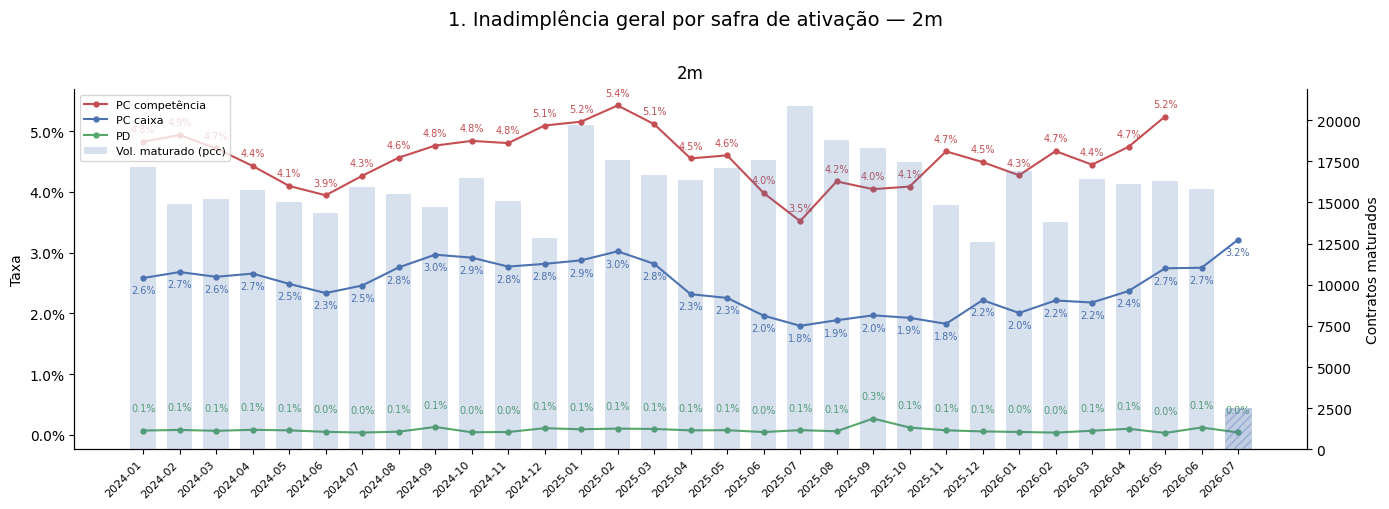

Público maturado (safras incompletas) — 2m


safra,n_ativados,n_maturados,pct_maturado
2026-07,"18,408","2,523",13.7%


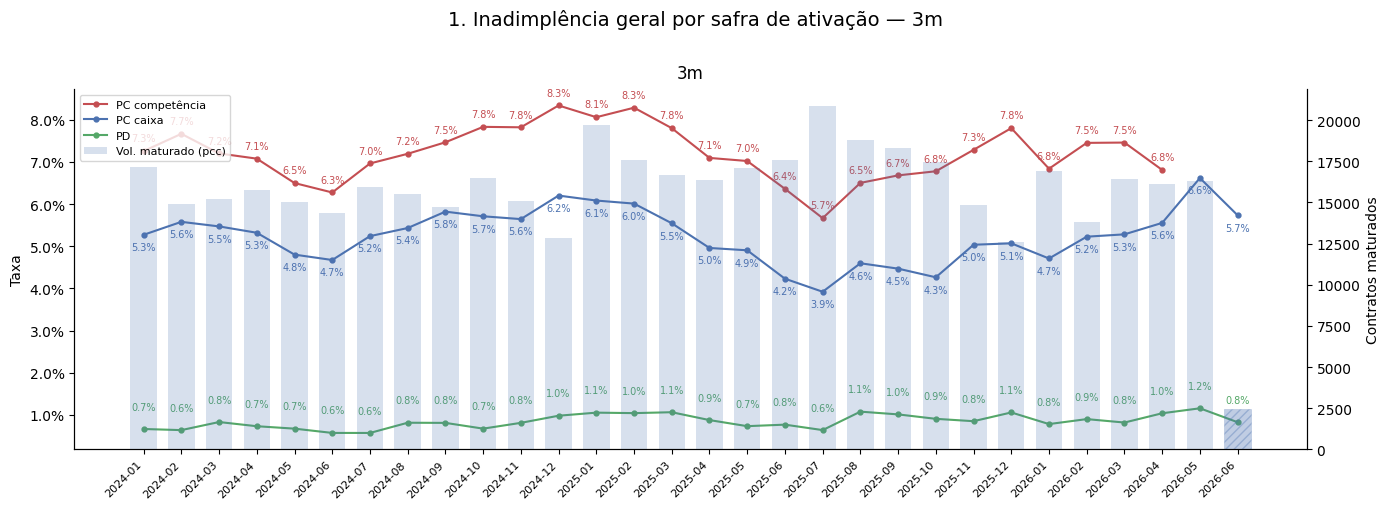

Público maturado (safras incompletas) — 3m


safra,n_ativados,n_maturados,pct_maturado
2026-06,"15,786","2,424",15.4%


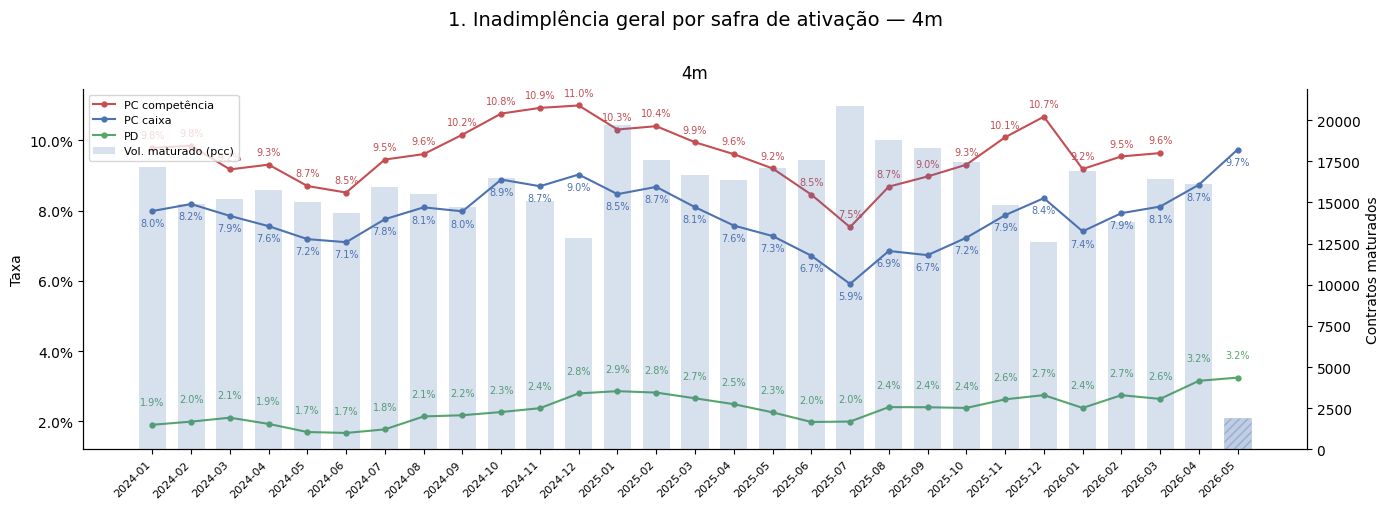

Público maturado (safras incompletas) — 4m


safra,n_ativados,n_maturados,pct_maturado
2026-05,"16,273","1,909",11.7%


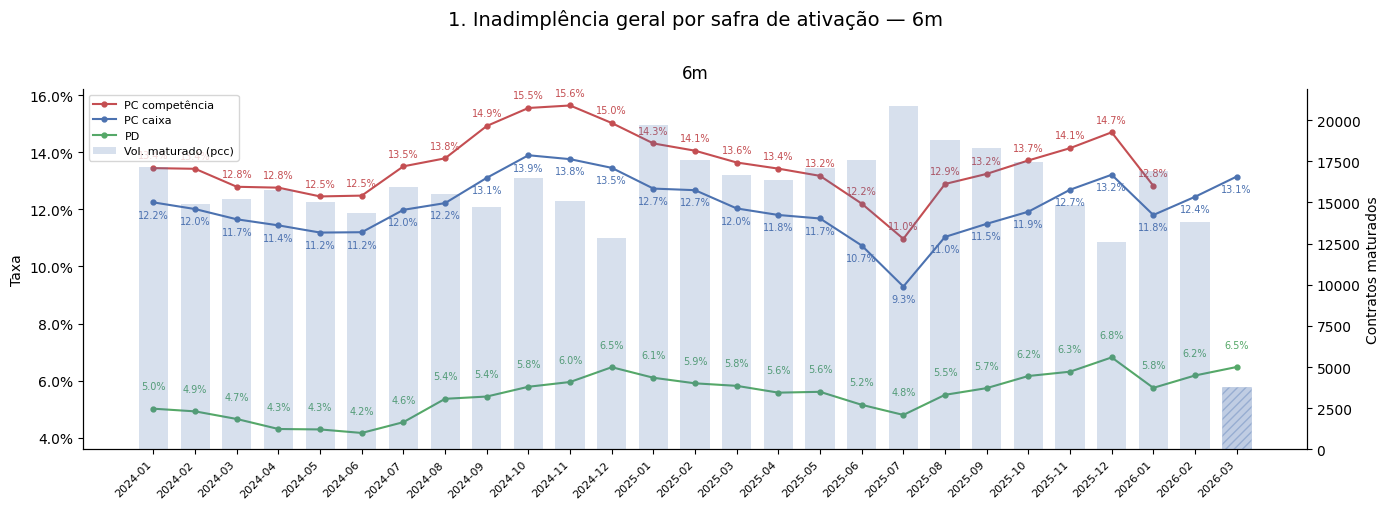

Público maturado (safras incompletas) — 6m


safra,n_ativados,n_maturados,pct_maturado
2026-03,"16,395","3,765",23.0%


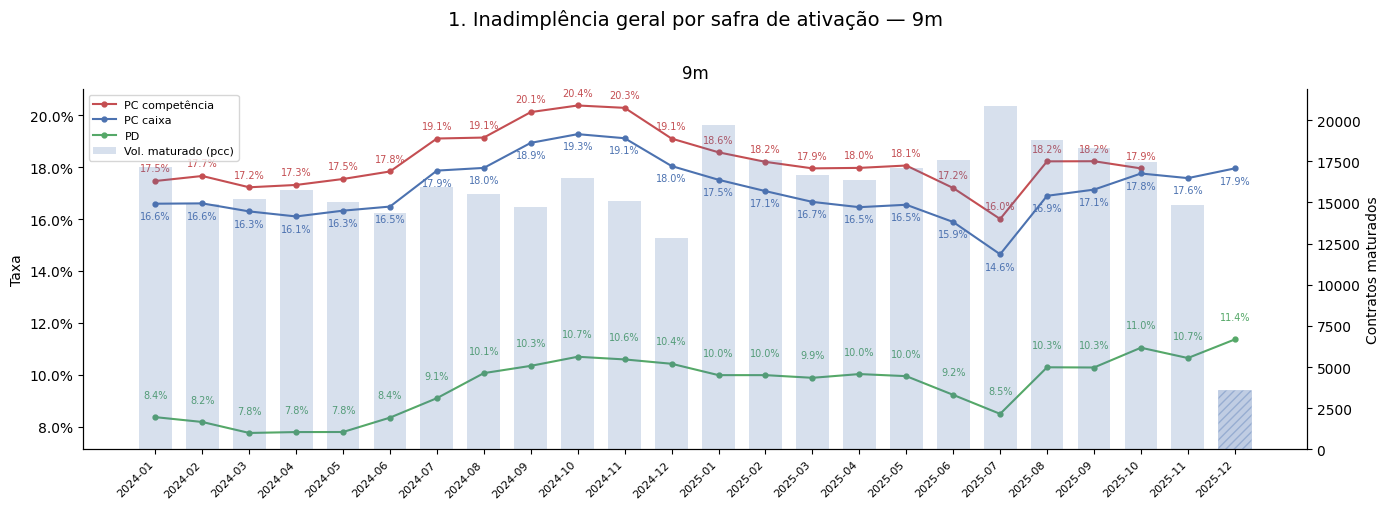

Público maturado (safras incompletas) — 9m


safra,n_ativados,n_maturados,pct_maturado
2025-12,"12,587","3,616",28.7%


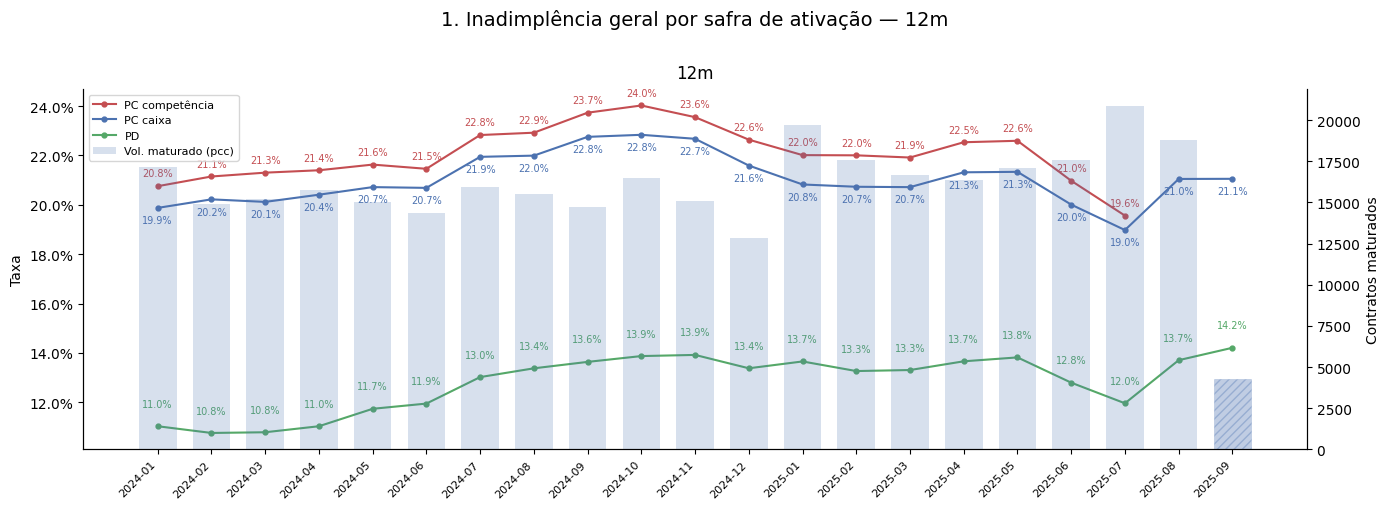

Público maturado (safras incompletas) — 12m


safra,n_ativados,n_maturados,pct_maturado
2025-09,"18,306","4,294",23.5%


In [350]:
show_rate_summary(df_ctr)
plot_default_grid(df_ctr, "1. Inadimplência geral por safra de ativação", windows=[2, 3])
plot_default_grid(df_ctr, "1. Inadimplência geral por safra de ativação", windows=[4, 6])
plot_default_grid(df_ctr, "1. Inadimplência geral por safra de ativação", windows=[9, 12])

## 1. Caso geral Uniproponente

Mesmo recorte do caso geral, só uniproponente (is_single_proponent = 1). Sem quebra por modelo.

,janela,n_ativados,n_maturados_pcc,pct_maturado,pc,pcc,pd
0,2m,"498,485","466,408",93.6%,4.65%,2.49%,0.08%
1,3m,"498,485","451,004",90.5%,7.35%,5.33%,0.88%
2,4m,"498,485","434,769",87.2%,9.76%,7.95%,2.41%
3,6m,"498,485","405,045",81.3%,13.83%,12.28%,5.63%
4,9m,"498,485","363,128",72.8%,18.58%,17.43%,9.82%
5,12m,"498,485","315,243",63.2%,22.54%,21.40%,13.09%


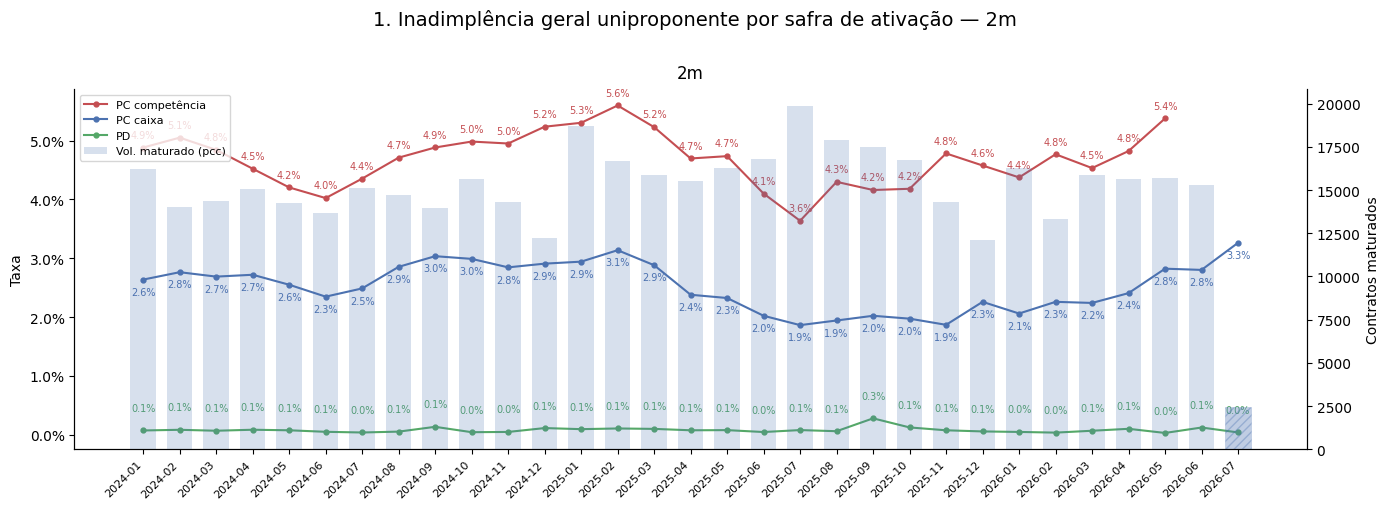

Público maturado (safras incompletas) — 2m


safra,n_ativados,n_maturados,pct_maturado
2026-07,"17,869","2,451",13.7%


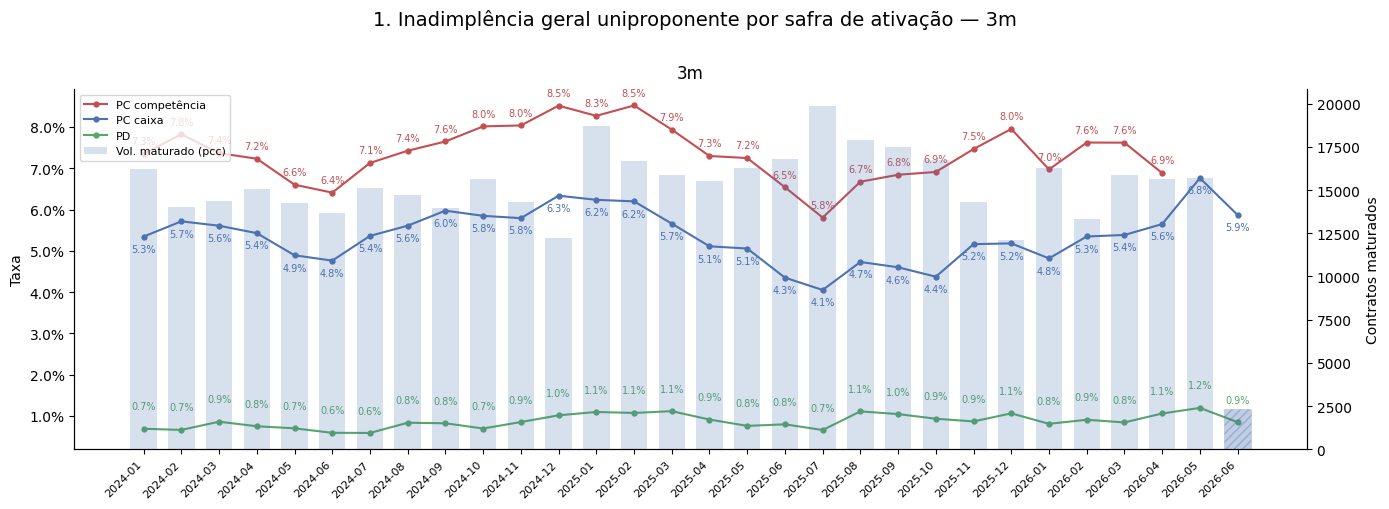

Público maturado (safras incompletas) — 3m


safra,n_ativados,n_maturados,pct_maturado
2026-06,"15,305","2,352",15.4%


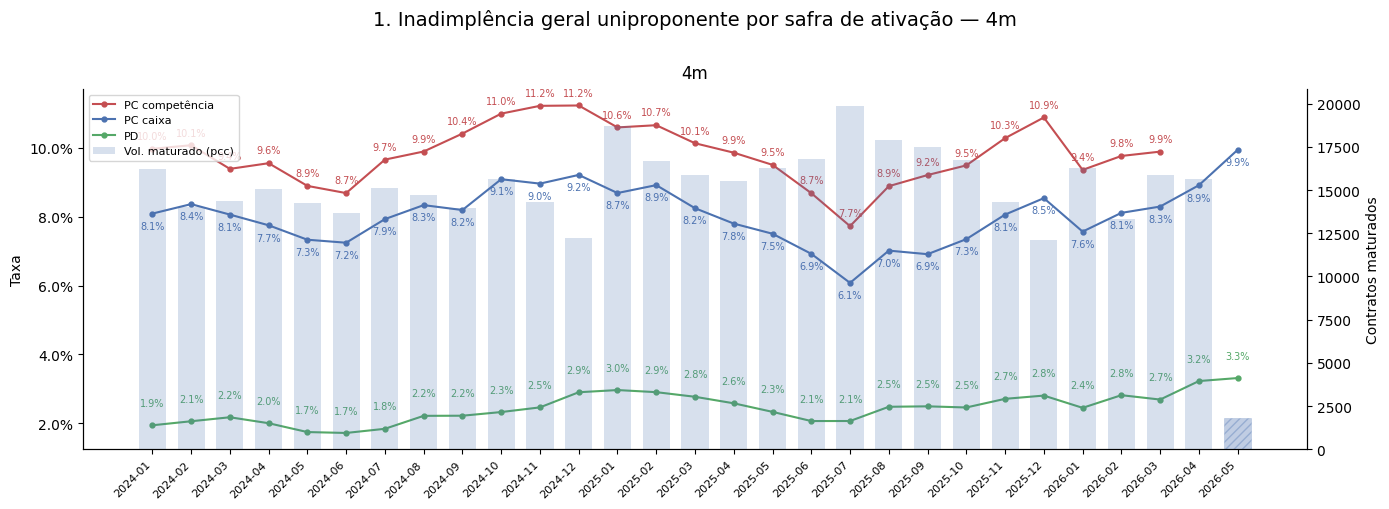

Público maturado (safras incompletas) — 4m


safra,n_ativados,n_maturados,pct_maturado
2026-05,"15,724","1,841",11.7%


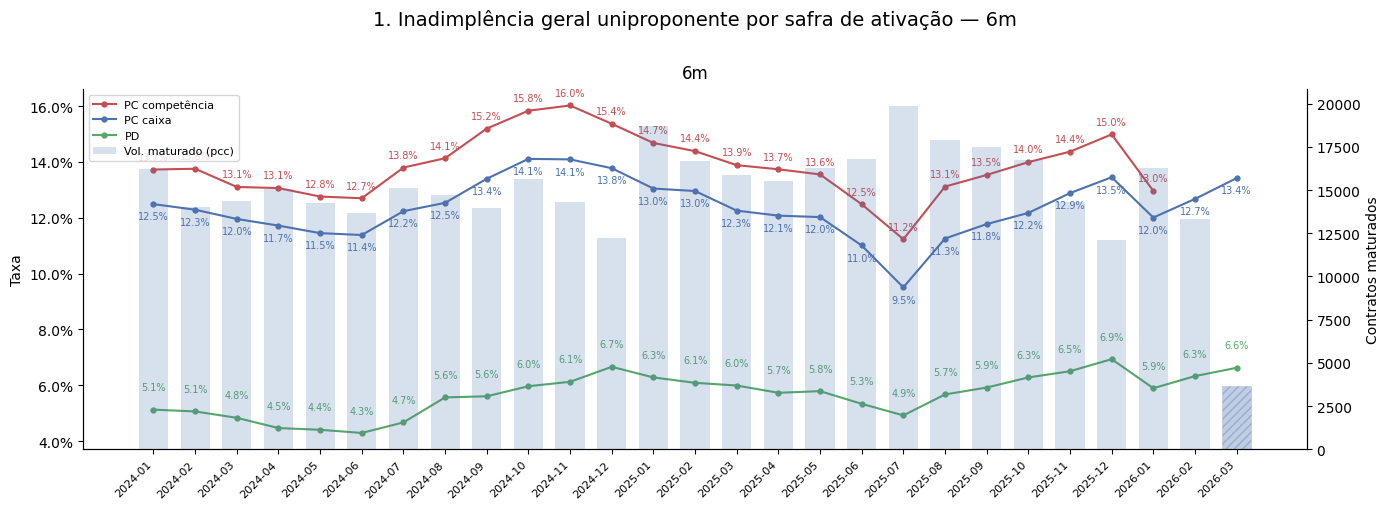

Público maturado (safras incompletas) — 6m


safra,n_ativados,n_maturados,pct_maturado
2026-03,"15,881","3,651",23.0%


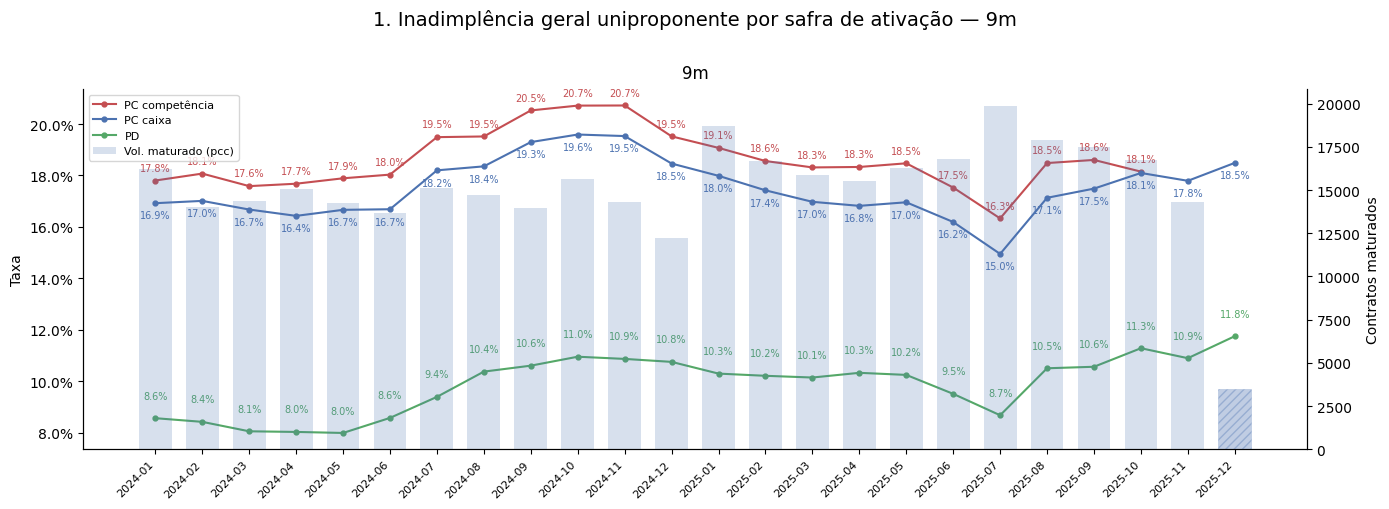

Público maturado (safras incompletas) — 9m


safra,n_ativados,n_maturados,pct_maturado
2025-12,"12,124","3,472",28.6%


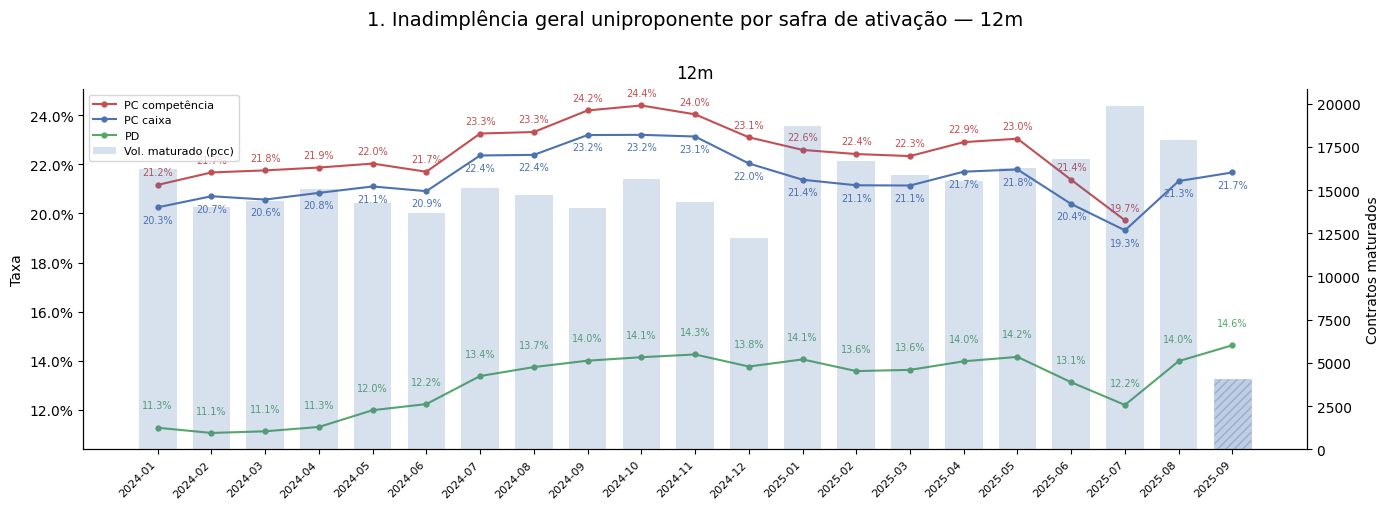

Público maturado (safras incompletas) — 12m


safra,n_ativados,n_maturados,pct_maturado
2025-09,"17,496","4,079",23.3%


In [351]:
df_uni_geral = df_ctr[df_ctr["is_single_proponent"] == 1].copy()
show_rate_summary(df_uni_geral)
plot_default_grid(df_uni_geral, "1. Inadimplência geral uniproponente por safra de ativação", windows=[2, 3])
plot_default_grid(df_uni_geral, "1. Inadimplência geral uniproponente por safra de ativação", windows=[4, 6])
plot_default_grid(df_uni_geral, "1. Inadimplência geral uniproponente por safra de ativação", windows=[9, 12])

## 1. Caso geral Uniproponente Sem Fallback

Uniproponente (is_single_proponent = 1) e score do blend principal (is_fallback = 0). Sem quebra por modelo.

,janela,n_ativados,n_maturados_pcc,pct_maturado,pc,pcc,pd
0,2m,"498,229","466,326",93.6%,4.65%,2.49%,0.08%
1,3m,"498,229","450,944",90.5%,7.35%,5.33%,0.88%
2,4m,"498,229","434,723",87.3%,9.76%,7.95%,2.41%
3,6m,"498,229","405,045",81.3%,13.83%,12.28%,5.63%
4,9m,"498,229","363,128",72.9%,18.58%,17.43%,9.82%
5,12m,"498,229","315,243",63.3%,22.54%,21.40%,13.09%


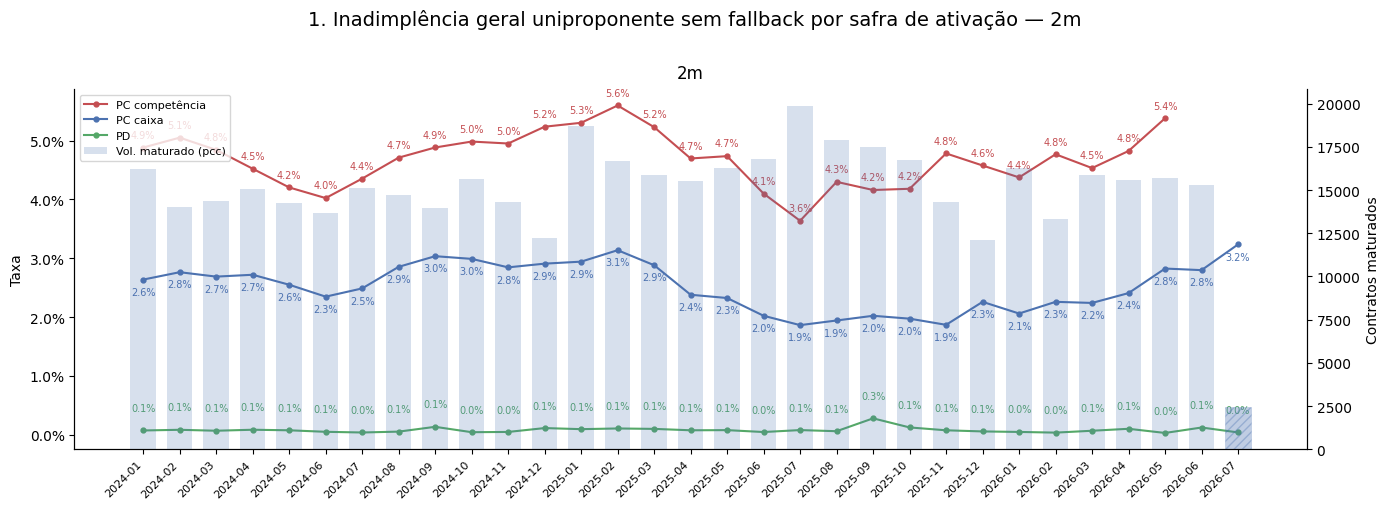

Público maturado (safras incompletas) — 2m


safra,n_ativados,n_maturados,pct_maturado
2026-07,"17,792","2,441",13.7%


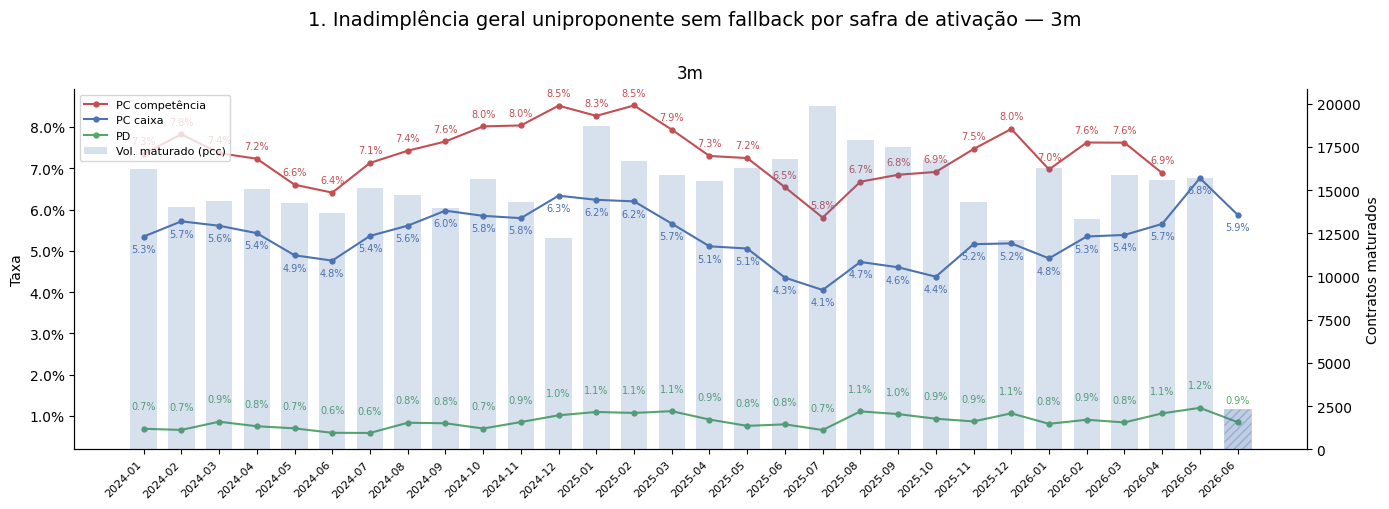

Público maturado (safras incompletas) — 3m


safra,n_ativados,n_maturados,pct_maturado
2026-06,"15,291","2,350",15.4%


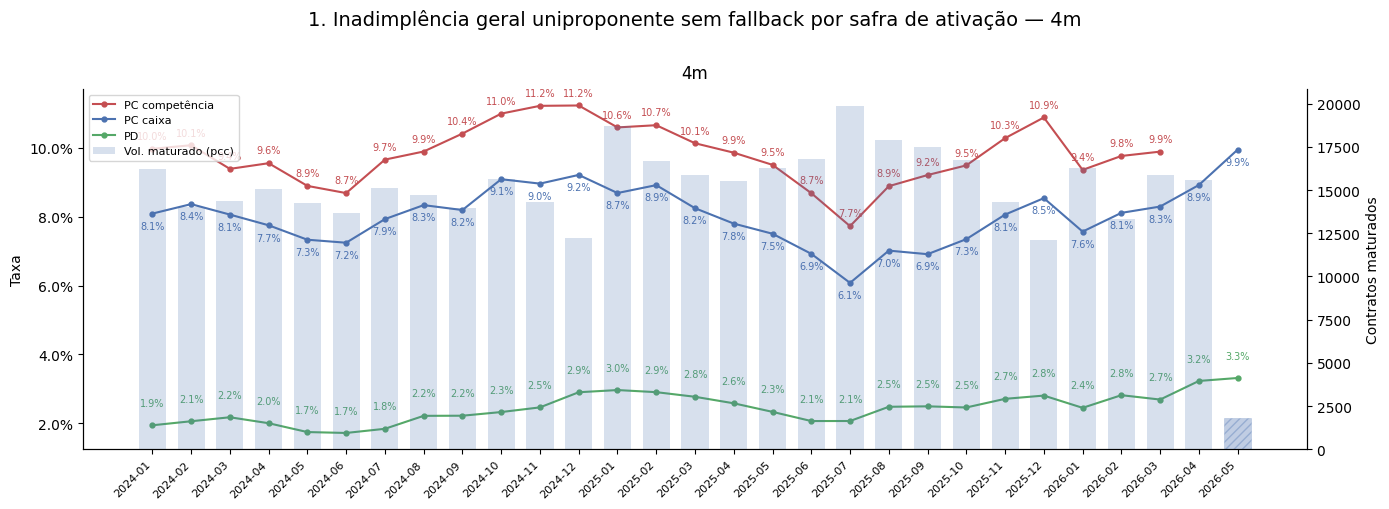

Público maturado (safras incompletas) — 4m


safra,n_ativados,n_maturados,pct_maturado
2026-05,"15,711","1,840",11.7%


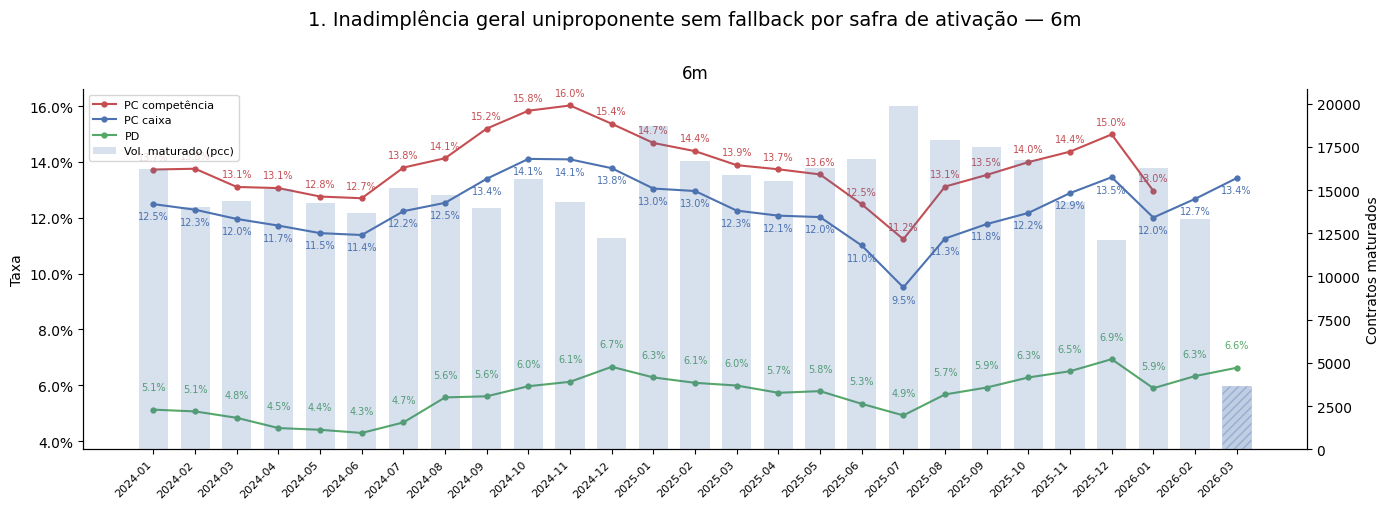

Público maturado (safras incompletas) — 6m


safra,n_ativados,n_maturados,pct_maturado
2026-03,"15,881","3,651",23.0%


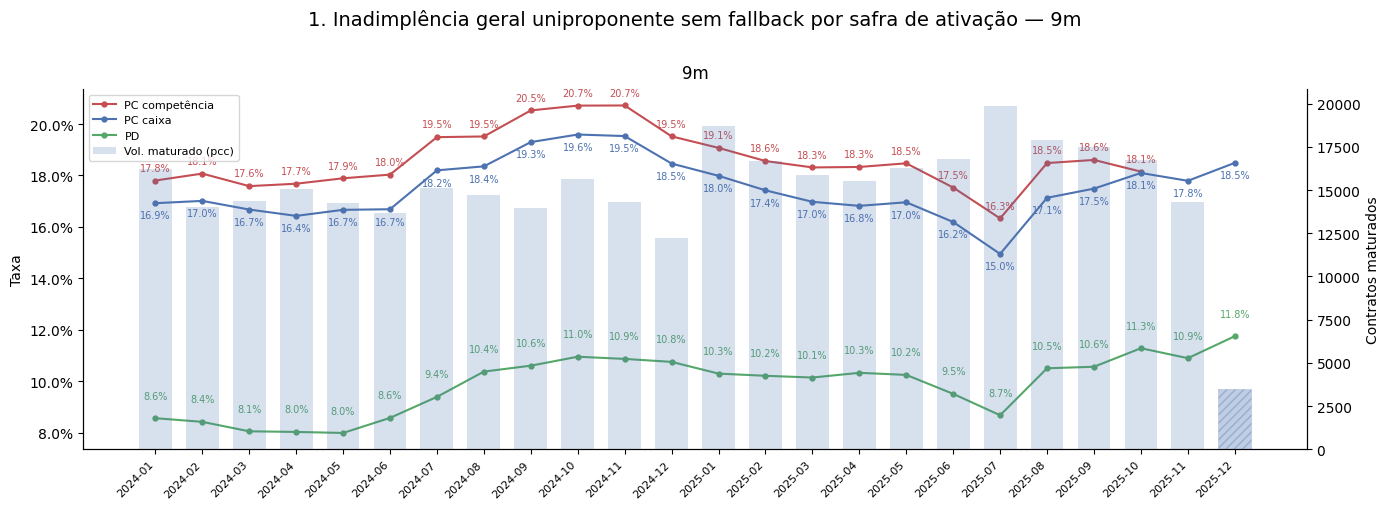

Público maturado (safras incompletas) — 9m


safra,n_ativados,n_maturados,pct_maturado
2025-12,"12,124","3,472",28.6%


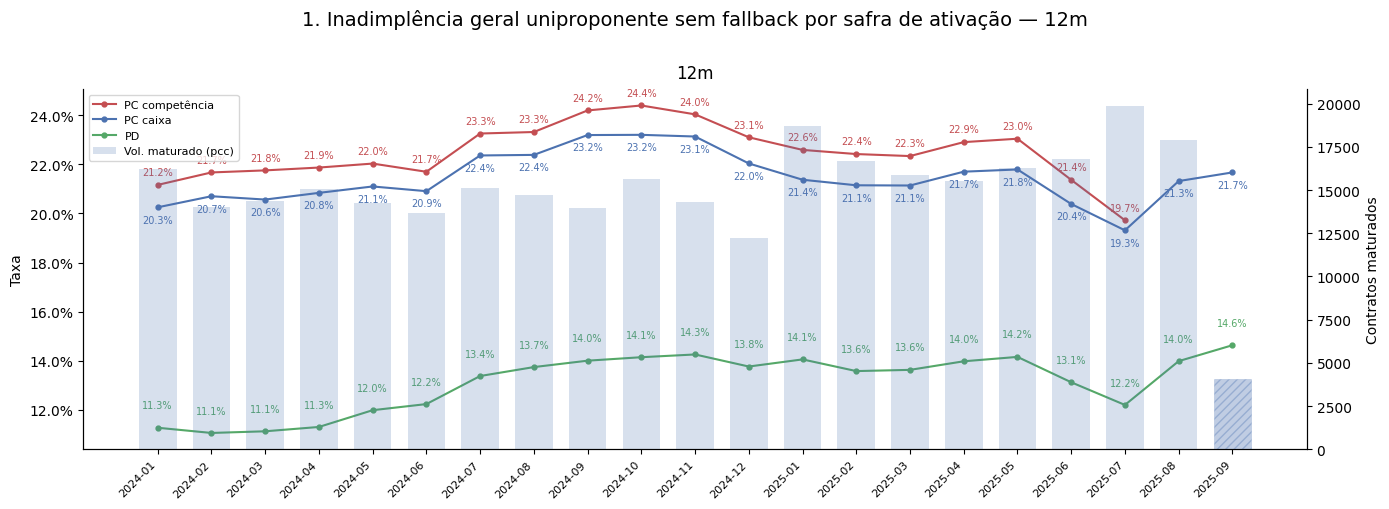

Público maturado (safras incompletas) — 12m


safra,n_ativados,n_maturados,pct_maturado
2025-09,"17,496","4,079",23.3%


In [352]:
df_uni_no_fallback = df_ctr[
    (df_ctr["is_single_proponent"] == 1) & (df_ctr["is_fallback"] == 0)
].copy()
show_rate_summary(df_uni_no_fallback)
plot_default_grid(
    df_uni_no_fallback,
    "1. Inadimplência geral uniproponente sem fallback por safra de ativação",
    windows=[2, 3],
)
plot_default_grid(
    df_uni_no_fallback,
    "1. Inadimplência geral uniproponente sem fallback por safra de ativação",
    windows=[4, 6],
)
plot_default_grid(
    df_uni_no_fallback,
    "1. Inadimplência geral uniproponente sem fallback por safra de ativação",
    windows=[9, 12],
)

## 2. Por modelo — todos os fallbacks e uni/multi

Mesmo público do caso geral, quebrado em `BLEND2` / `BLEND3` / `BLEND4`.

Séries a partir de 2026-01 (BLEND2), 2026-04 (BLEND3) e 2026-07 (BLEND4).

Janelas desta seção: `WINDOWS_BY_MODEL` (hoje 2m, 3m, 4m e 6m). Para incluir 9m/12m, edite essa lista na célula de funções.

In [353]:
WINDOWS_BY_MODEL

[2, 3, 4, 6]

,janela,n_ativados,n_maturados_pcc,pct_maturado,pc,pcc,pd
0,2m,"92,713","60,653",65.4%,4.89%,2.62%,0.08%
1,3m,"92,713","45,196",48.7%,7.55%,5.95%,1.02%
2,4m,"92,713","28,917",31.2%,9.60%,8.62%,2.99%
3,6m,"92,713","5,426",5.9%,,12.53%,5.86%


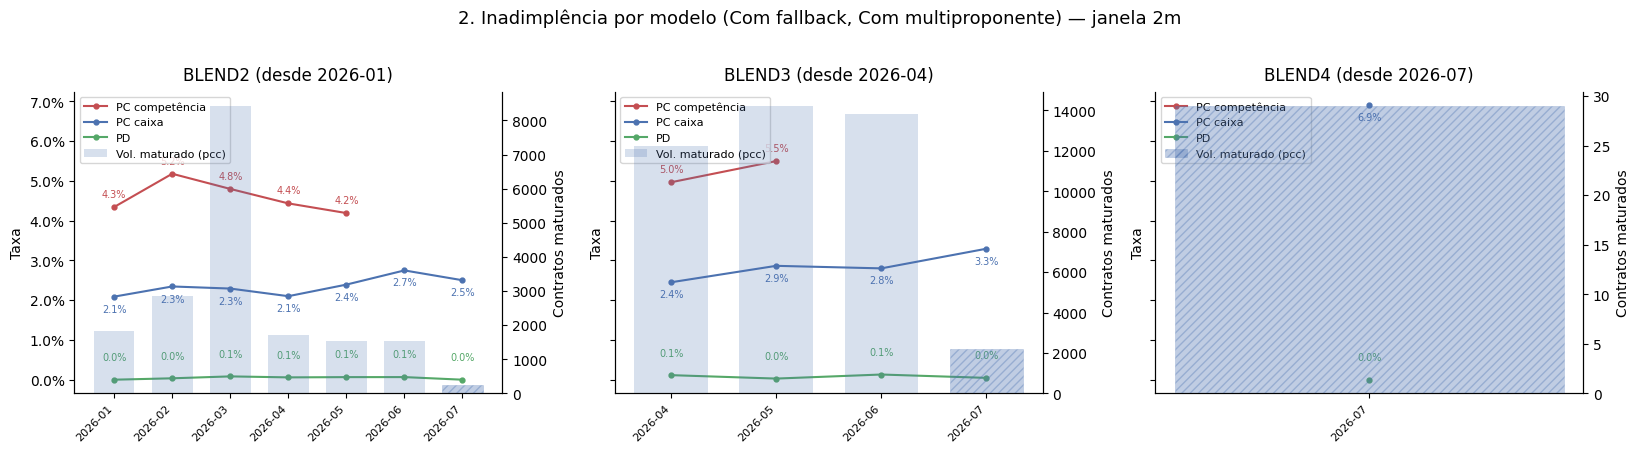

Público maturado (safras incompletas) — 2m


modelo,safra,n_ativados,n_maturados,pct_maturado
BLEND2,2026-07,314,240,76.4%
BLEND3,2026-07,"15,442","2,187",14.2%
BLEND4,2026-07,"2,101",29,1.4%


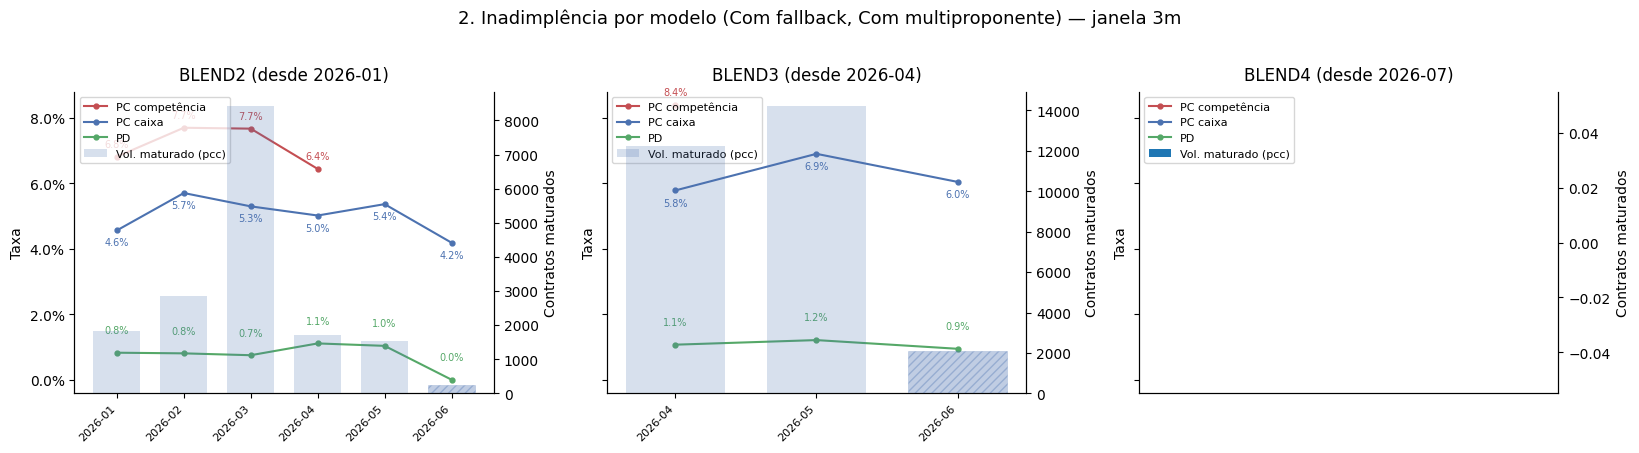

Público maturado (safras incompletas) — 3m


modelo,safra,n_ativados,n_maturados,pct_maturado
BLEND2,2026-06,"1,529",239,15.6%
BLEND3,2026-06,"13,830","2,119",15.3%


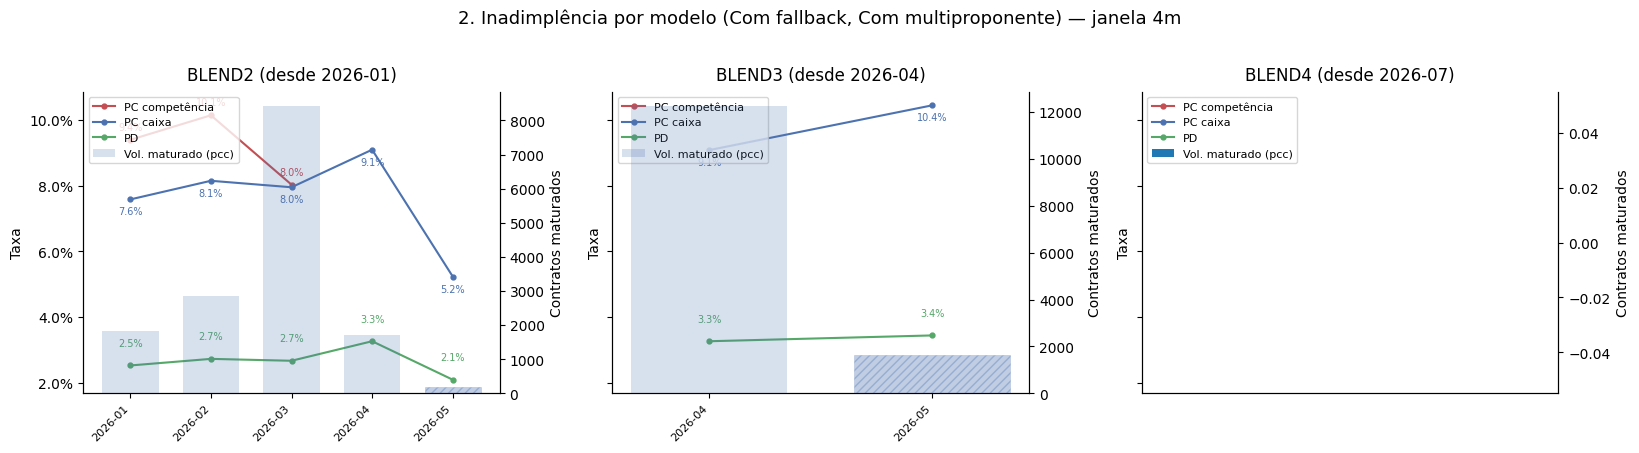

Público maturado (safras incompletas) — 4m


modelo,safra,n_ativados,n_maturados,pct_maturado
BLEND2,2026-05,"1,548",191,12.3%
BLEND3,2026-05,"14,220","1,656",11.6%


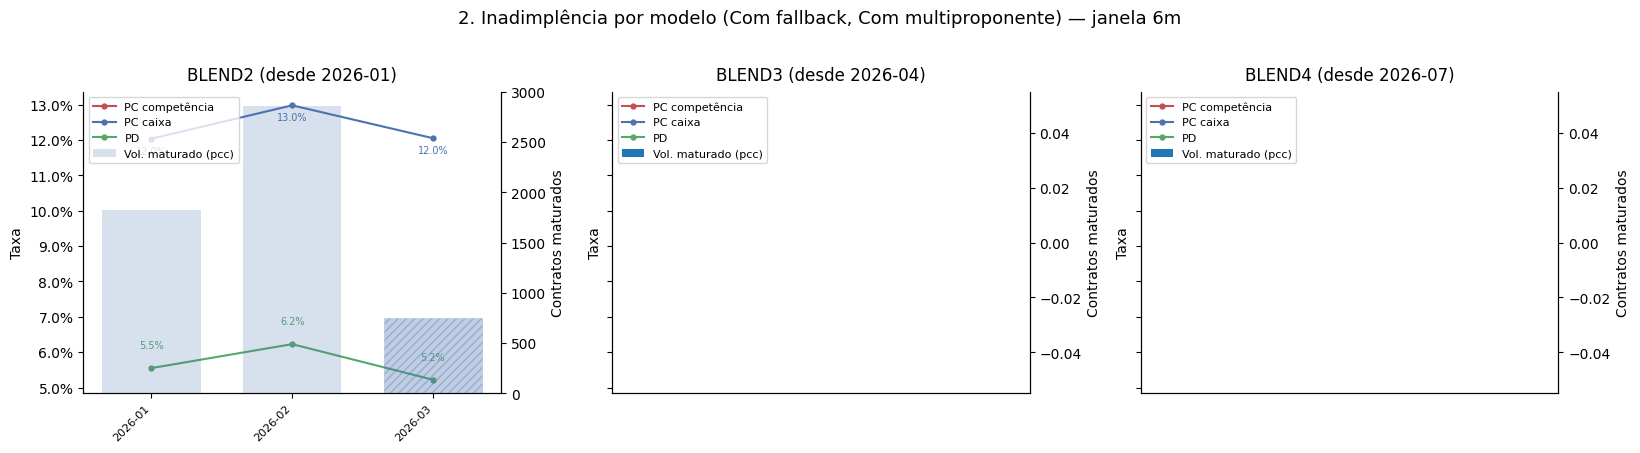

Público maturado (safras incompletas) — 6m


modelo,safra,n_ativados,n_maturados,pct_maturado
BLEND2,2026-03,"8,425",747,8.9%


In [354]:
df_model = filter_model_safras(df_ctr)
show_rate_summary(df_model, windows=WINDOWS_BY_MODEL)
plot_default_by_model(
    df_ctr,
    "2. Inadimplência por modelo (Com fallback, Com multiproponente)",
    windows=WINDOWS_BY_MODEL,
)

## 3. Por modelo — sem fallback (is_fallback = 0)

Score veio do blend principal. Uni e multi entram juntos.

,janela,n_ativados,n_maturados_pcc,pct_maturado,pc,pcc,pd
0,2m,"92,457","60,571",65.5%,4.89%,2.62%,0.08%
1,3m,"92,457","45,136",48.8%,7.55%,5.95%,1.02%
2,4m,"92,457","28,871",31.2%,9.60%,8.62%,3.00%
3,6m,"92,457","5,426",5.9%,,12.53%,5.86%


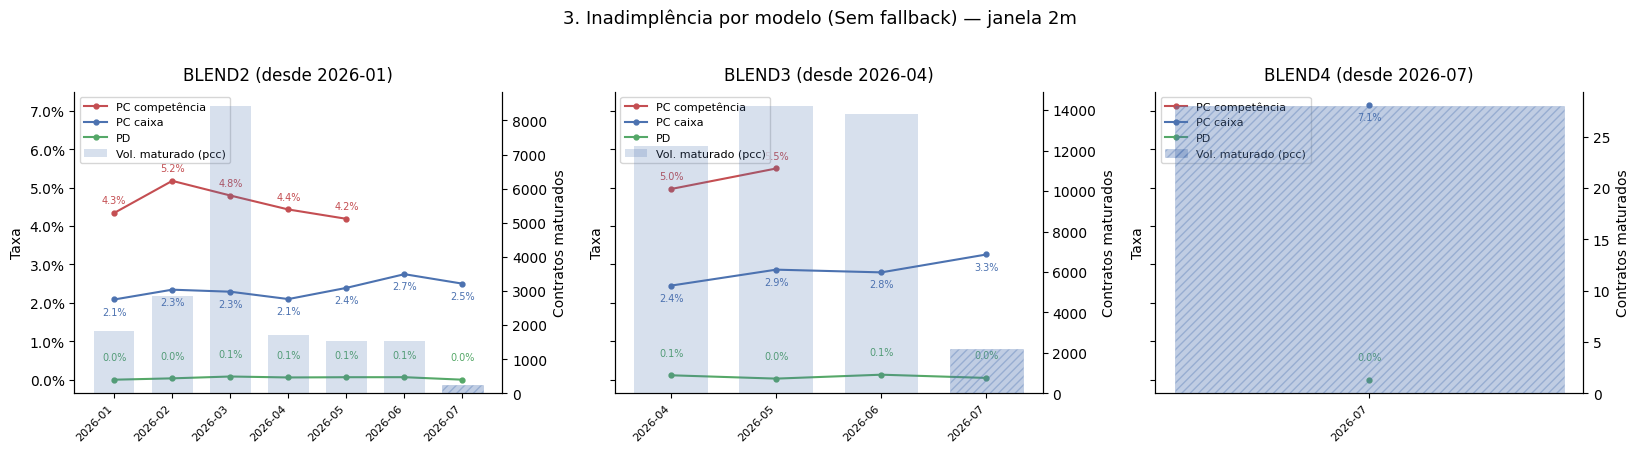

Público maturado (safras incompletas) — 2m


modelo,safra,n_ativados,n_maturados,pct_maturado
BLEND2,2026-07,314,240,76.4%
BLEND3,2026-07,"15,397","2,178",14.1%
BLEND4,2026-07,"2,069",28,1.4%


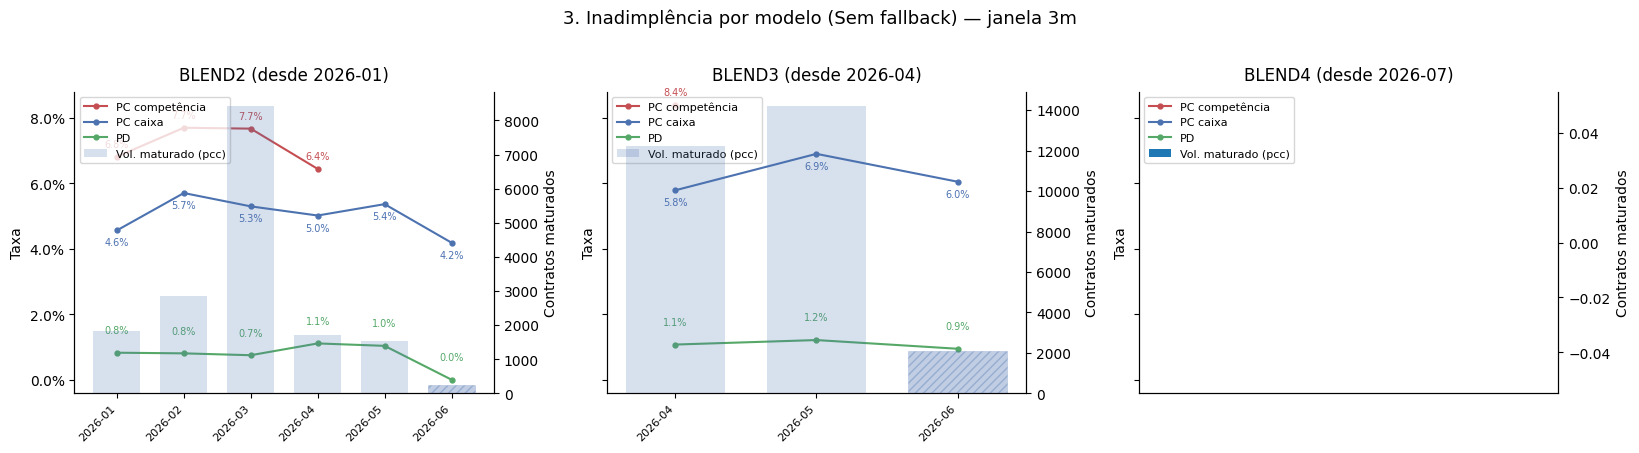

Público maturado (safras incompletas) — 3m


modelo,safra,n_ativados,n_maturados,pct_maturado
BLEND2,2026-06,"1,529",239,15.6%
BLEND3,2026-06,"13,816","2,117",15.3%


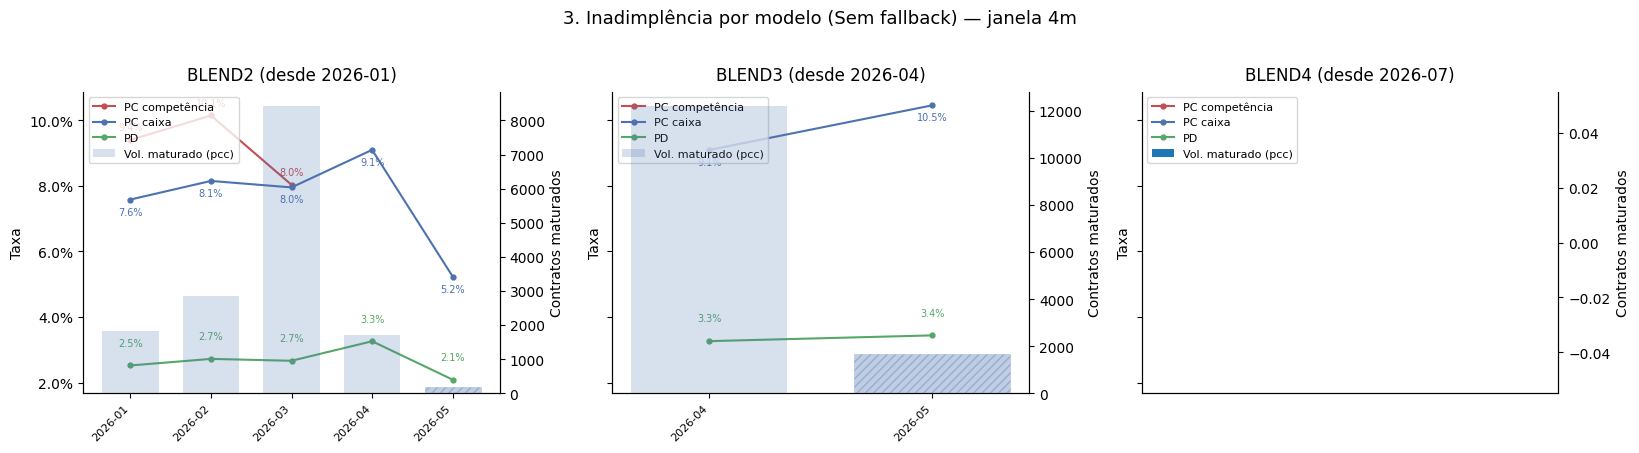

Público maturado (safras incompletas) — 4m


modelo,safra,n_ativados,n_maturados,pct_maturado
BLEND2,2026-05,"1,548",191,12.3%
BLEND3,2026-05,"14,207","1,655",11.6%


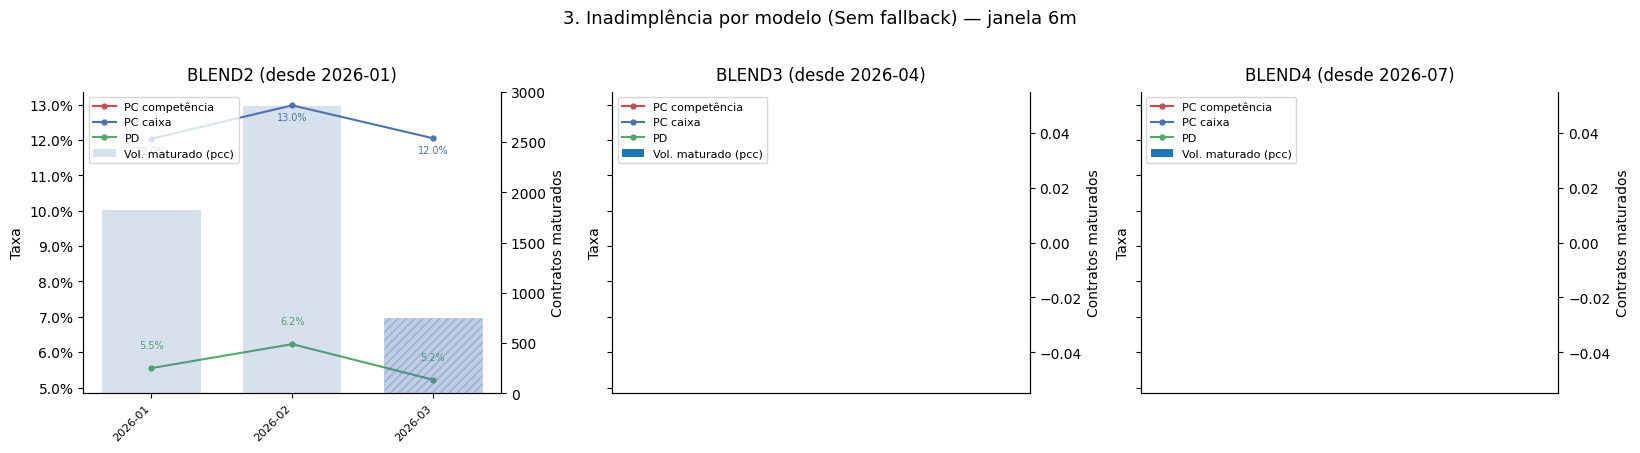

Público maturado (safras incompletas) — 6m


modelo,safra,n_ativados,n_maturados,pct_maturado
BLEND2,2026-03,"8,425",747,8.9%


In [355]:
df_no_fallback = filter_model_safras(df_ctr[df_ctr["is_fallback"] == 0])
show_rate_summary(df_no_fallback, windows=WINDOWS_BY_MODEL)
plot_default_by_model(
    df_no_fallback,
    "3. Inadimplência por modelo (Sem fallback)",
    windows=WINDOWS_BY_MODEL,
)

## 4. Por modelo — sem fallback e uniproponente

Público mais limpo para comparar gerações: is_fallback = 0 e is_single_proponent = 1.

,janela,n_ativados,n_maturados_pcc,pct_maturado,pc,pcc,pd
0,2m,"91,880","59,998",65.3%,4.96%,2.64%,0.08%
1,3m,"91,880","44,616",48.6%,7.72%,6.00%,1.03%
2,4m,"91,880","28,406",30.9%,9.83%,8.72%,3.03%
3,6m,"91,880","5,260",5.7%,,12.79%,5.99%
4,9m,"91,880",0,0.0%,,,
5,12m,"91,880",0,0.0%,,,


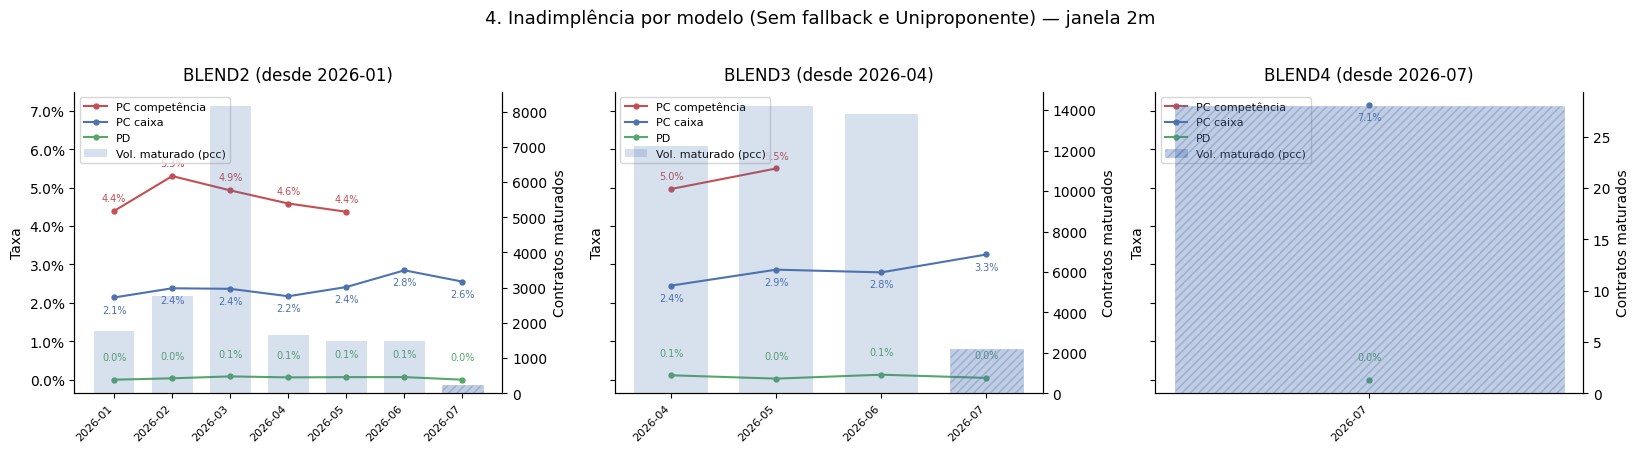

Público maturado (safras incompletas) — 2m


modelo,safra,n_ativados,n_maturados,pct_maturado
BLEND2,2026-07,306,235,76.8%
BLEND3,2026-07,"15,396","2,178",14.1%
BLEND4,2026-07,"2,069",28,1.4%


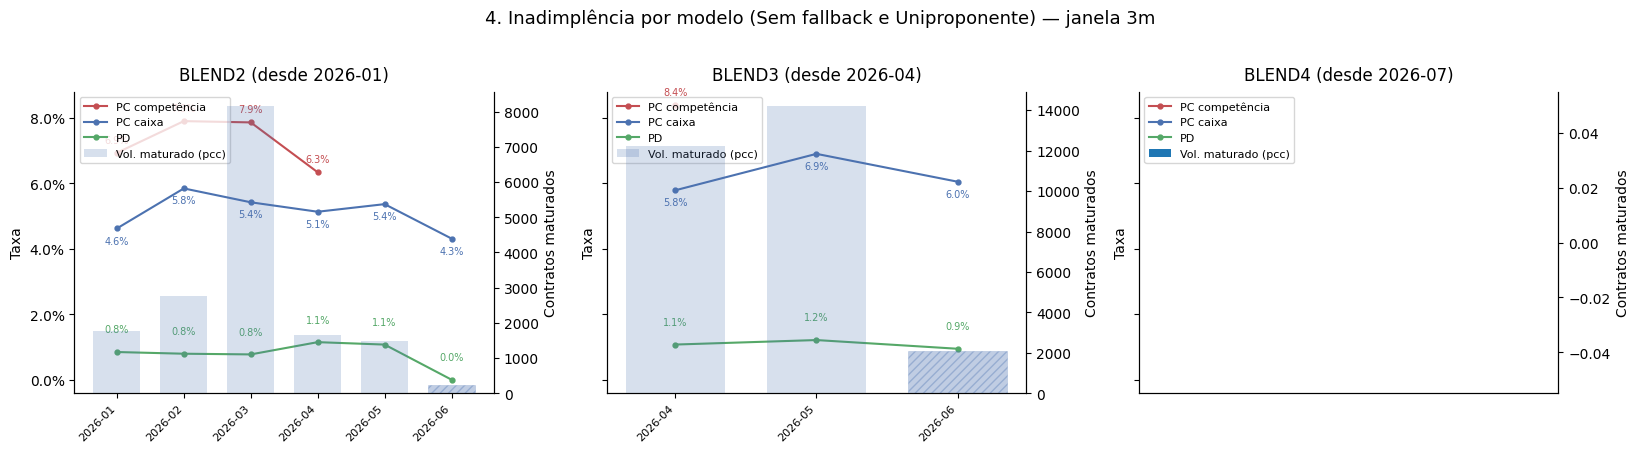

Público maturado (safras incompletas) — 3m


modelo,safra,n_ativados,n_maturados,pct_maturado
BLEND2,2026-06,"1,475",232,15.7%
BLEND3,2026-06,"13,815","2,117",15.3%


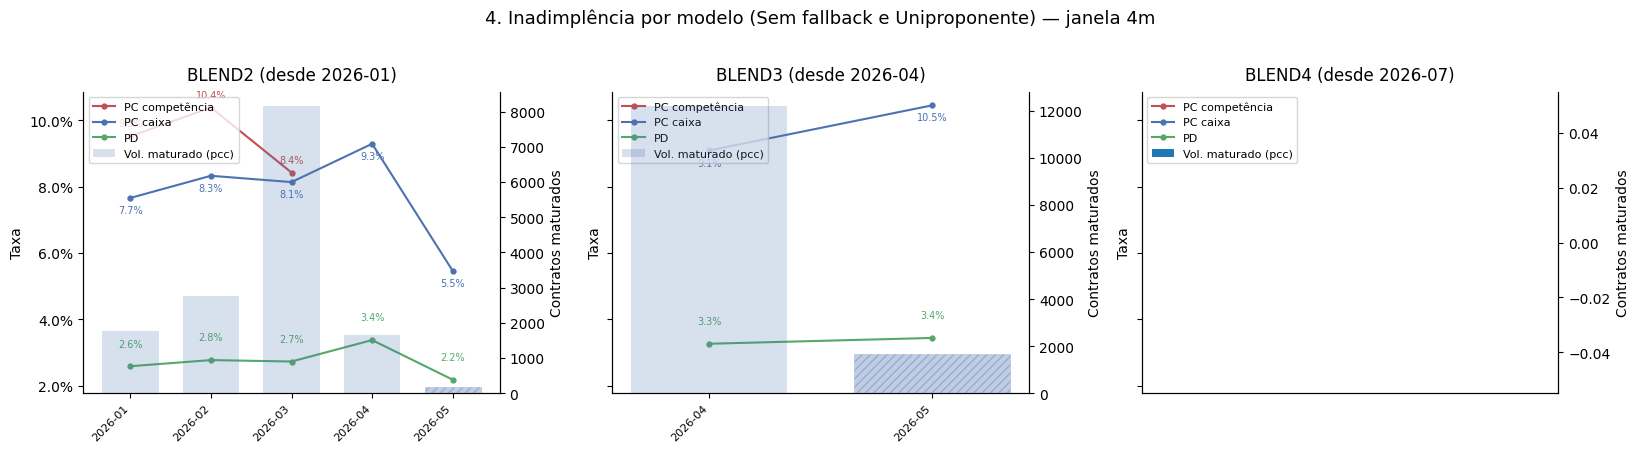

Público maturado (safras incompletas) — 4m


modelo,safra,n_ativados,n_maturados,pct_maturado
BLEND2,2026-05,"1,492",183,12.3%
BLEND3,2026-05,"14,207","1,655",11.6%


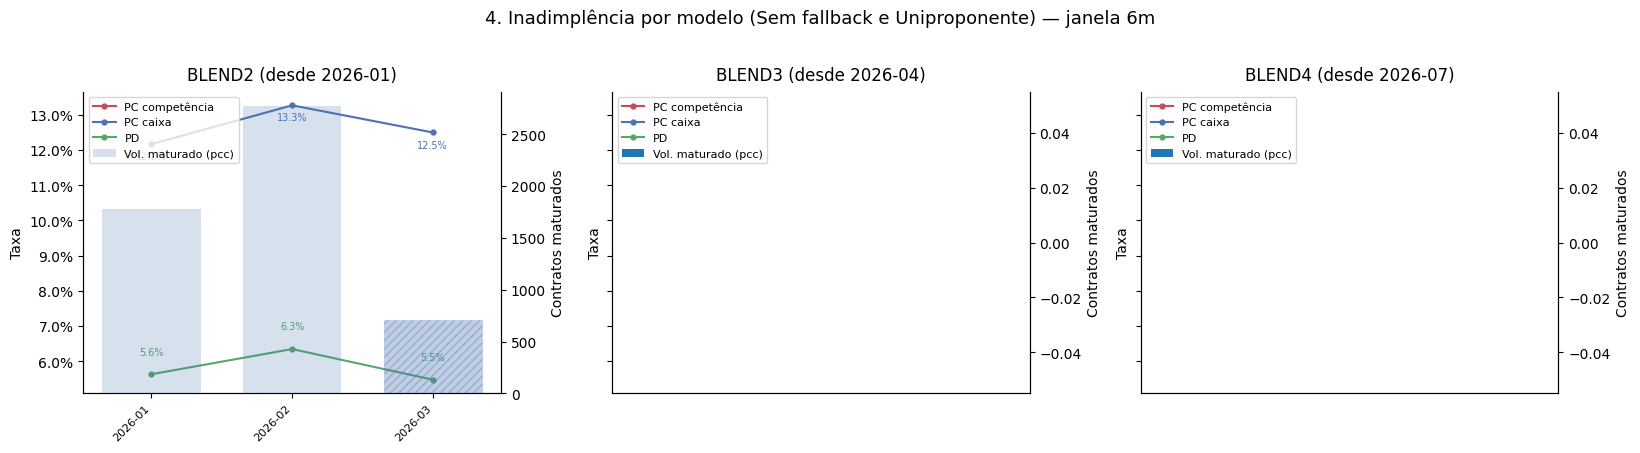

Público maturado (safras incompletas) — 6m


modelo,safra,n_ativados,n_maturados,pct_maturado
BLEND2,2026-03,"8,157",712,8.7%


In [356]:
df_uni_core = filter_model_safras(
    df_ctr[(df_ctr["is_fallback"] == 0) & (df_ctr["is_single_proponent"] == 1)]
)
show_rate_summary(df_uni_core)
plot_default_by_model(df_uni_core, "4. Inadimplência por modelo (Sem fallback e Uniproponente)")

## 5. Multiproponente

Visão agregada, sem quebra por modelo. Três figuras: 2m+3m, 4m+6m e 9m+12m.

,janela,n_ativados,n_maturados_pcc,pct_maturado,pc,pcc,pd
0,2m,"23,076","22,067",95.6%,2.10%,1.07%,0.00%
1,3m,"23,076","21,586",93.5%,3.80%,2.56%,0.24%
2,4m,"23,076","21,033",91.1%,5.12%,4.02%,0.82%
3,6m,"23,076","20,121",87.2%,7.65%,6.70%,2.29%
4,9m,"23,076","18,604",80.6%,11.16%,10.29%,4.61%
5,12m,"23,076","16,574",71.8%,14.06%,13.25%,6.61%


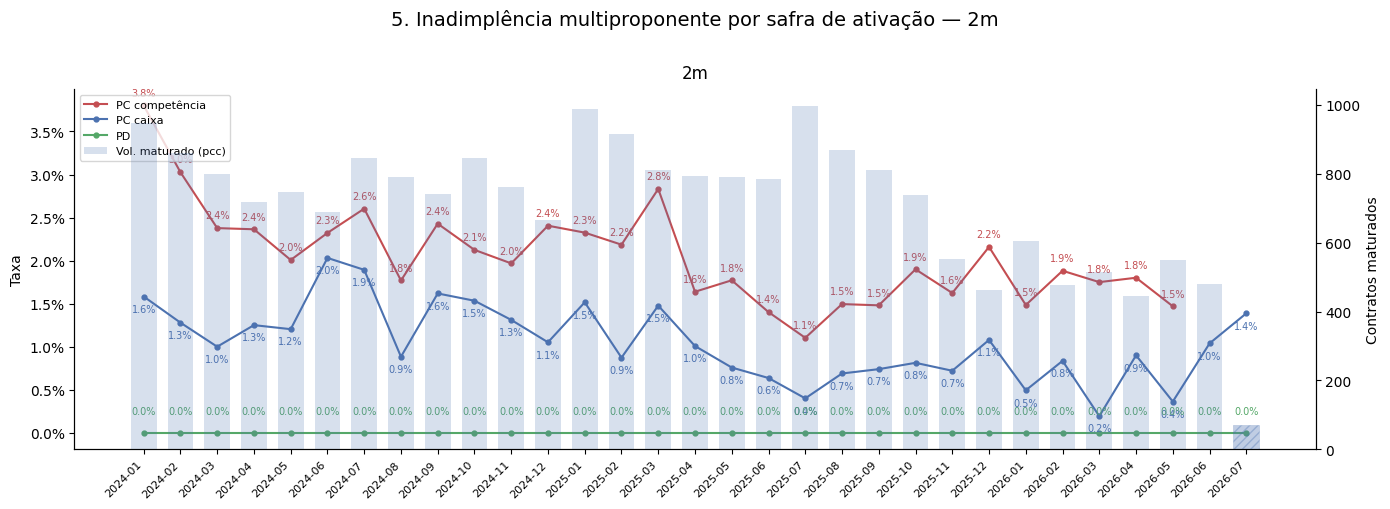

Público maturado (safras incompletas) — 2m


safra,n_ativados,n_maturados,pct_maturado
2026-07,539,72,13.4%


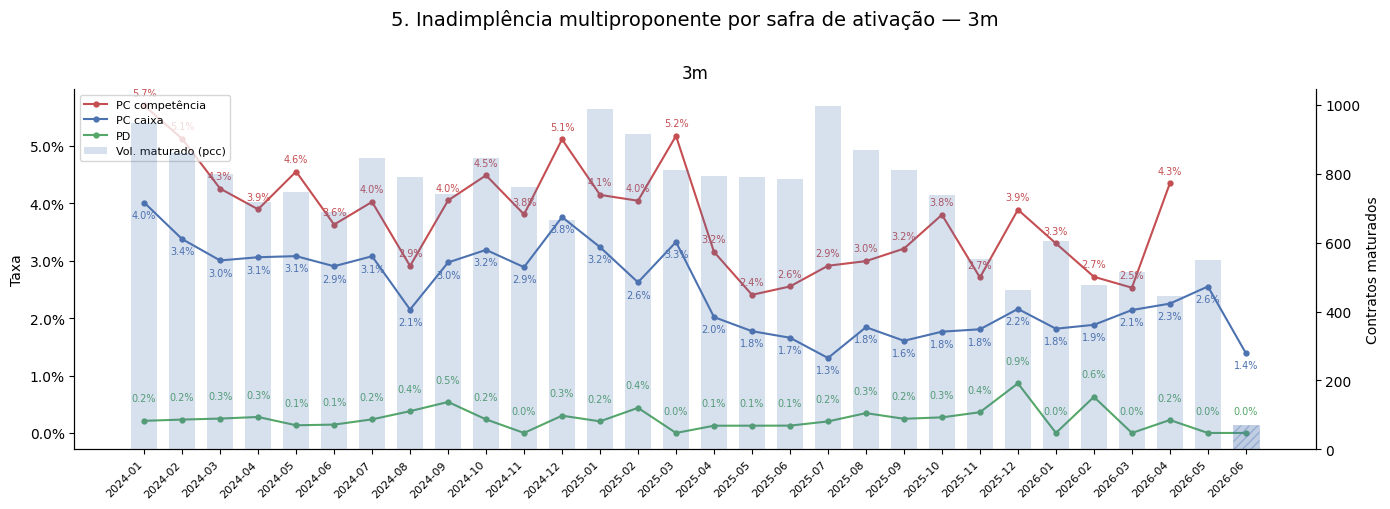

Público maturado (safras incompletas) — 3m


safra,n_ativados,n_maturados,pct_maturado
2026-06,481,72,15.0%


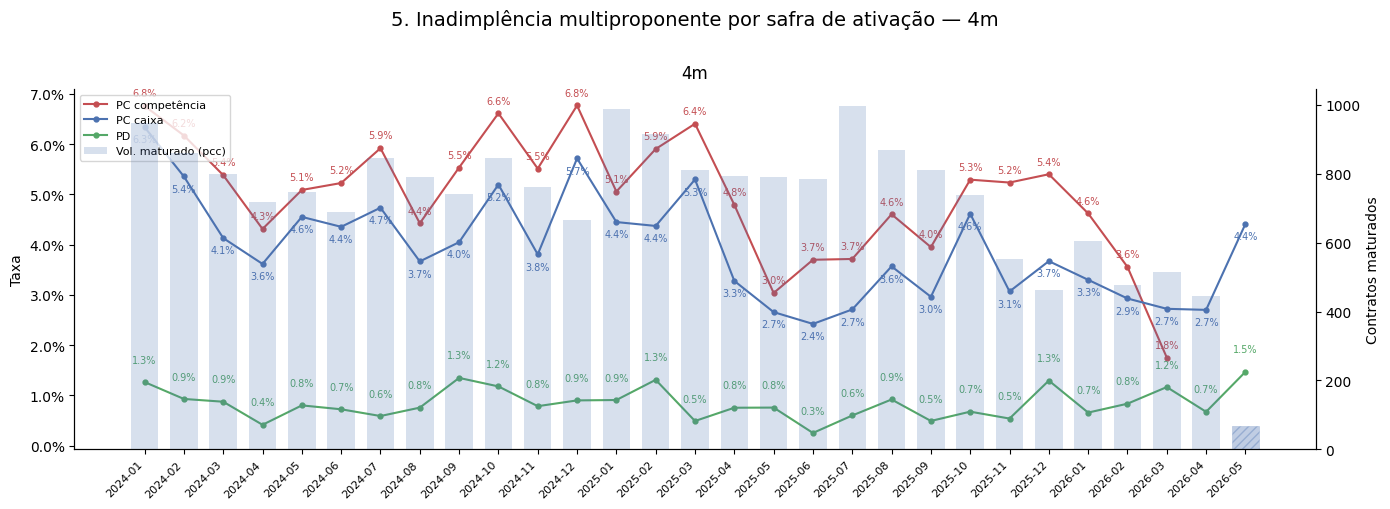

Público maturado (safras incompletas) — 4m


safra,n_ativados,n_maturados,pct_maturado
2026-05,549,68,12.4%


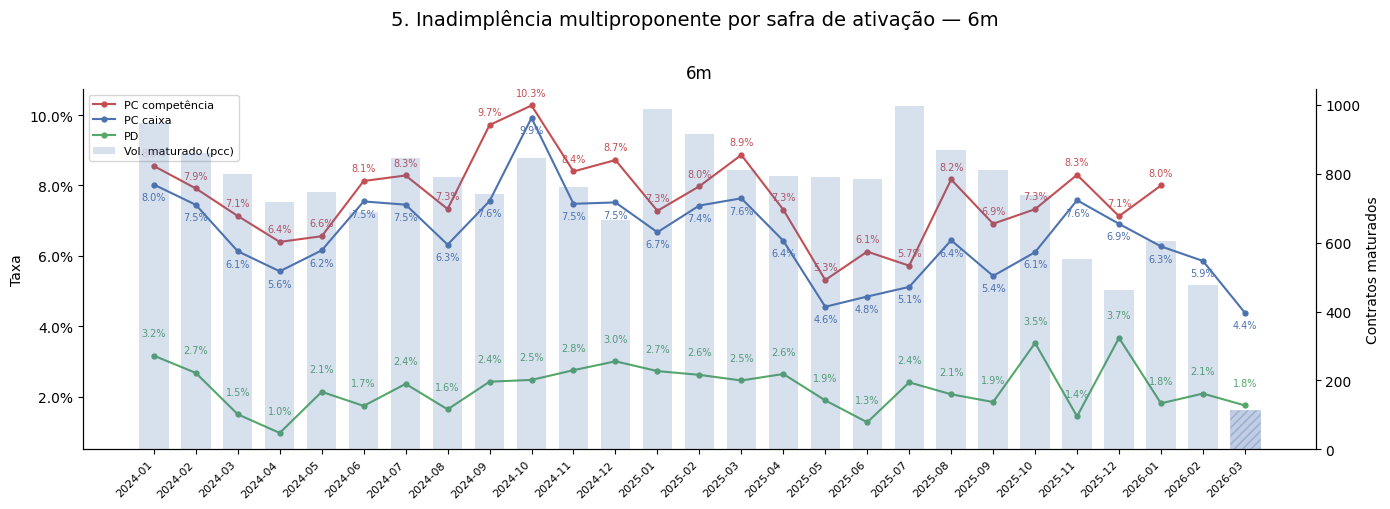

Público maturado (safras incompletas) — 6m


safra,n_ativados,n_maturados,pct_maturado
2026-03,514,114,22.2%


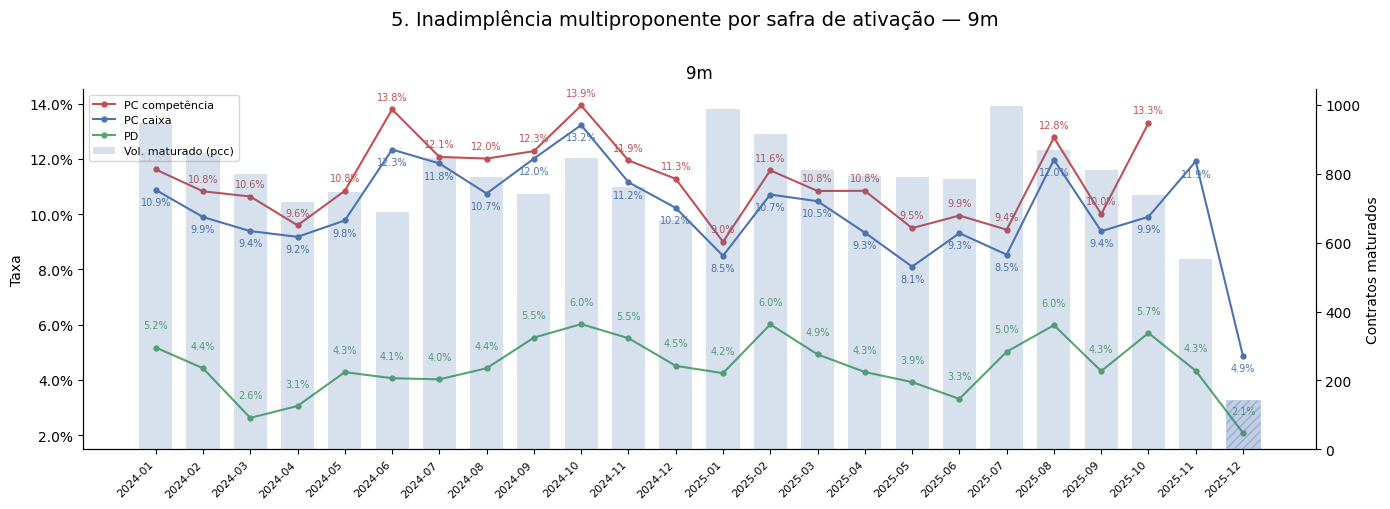

Público maturado (safras incompletas) — 9m


safra,n_ativados,n_maturados,pct_maturado
2025-12,463,144,31.1%


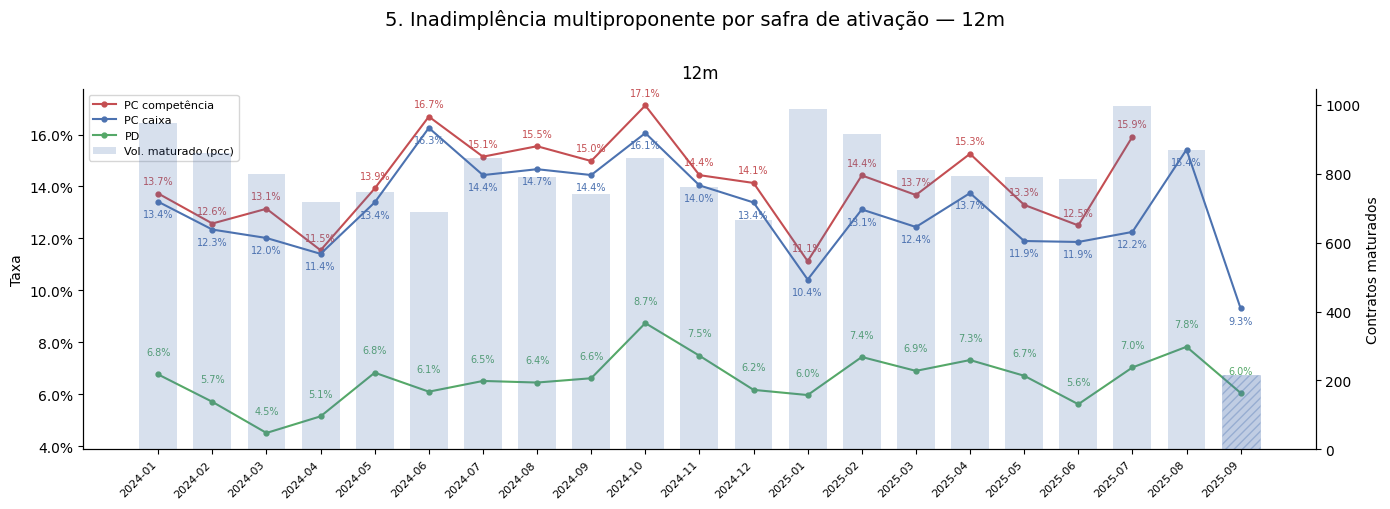

Público maturado (safras incompletas) — 12m


safra,n_ativados,n_maturados,pct_maturado
2025-09,810,215,26.5%


In [357]:
df_multi = df_ctr[df_ctr["is_single_proponent"] == 0].copy()
show_rate_summary(df_multi)
plot_default_grid(df_multi, "5. Inadimplência multiproponente por safra de ativação")

## 6. Mix ao longo da safra

Taxa sobe por piora do risco ou porque o mix mudou (mais Blend2, mais fallback, mais multi). Estes três gráficos separam o efeito.

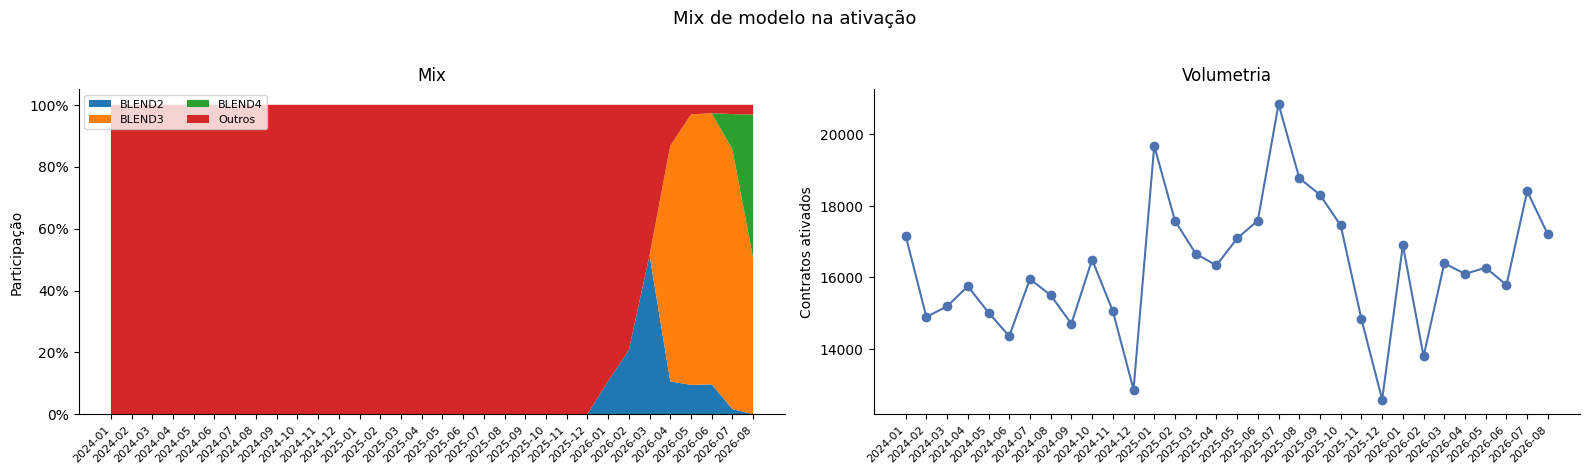

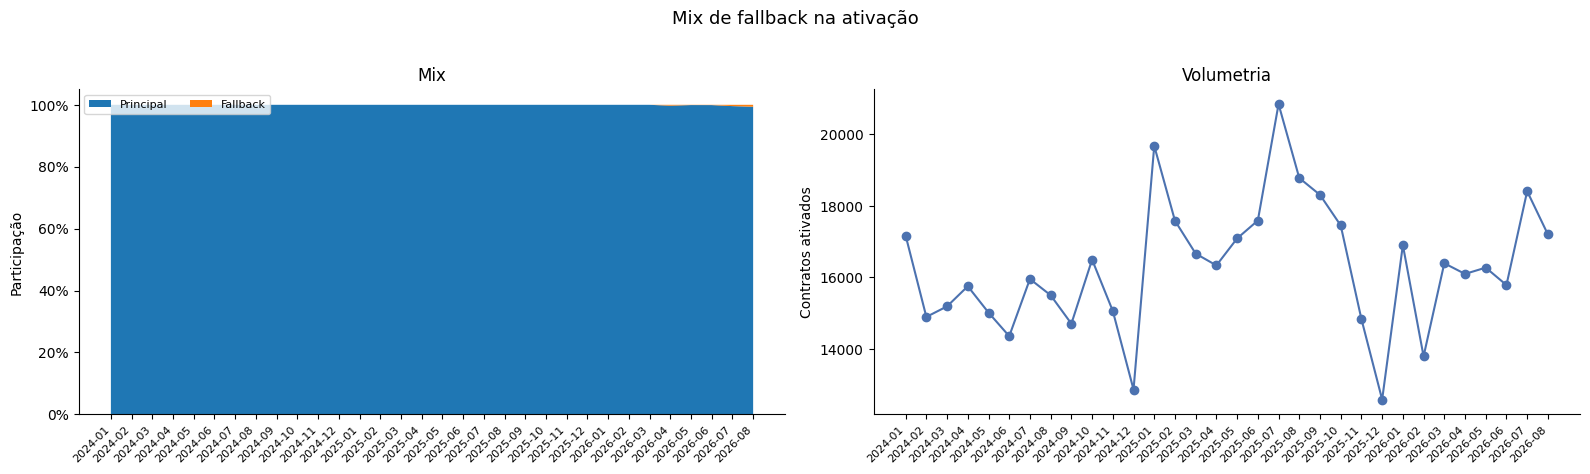

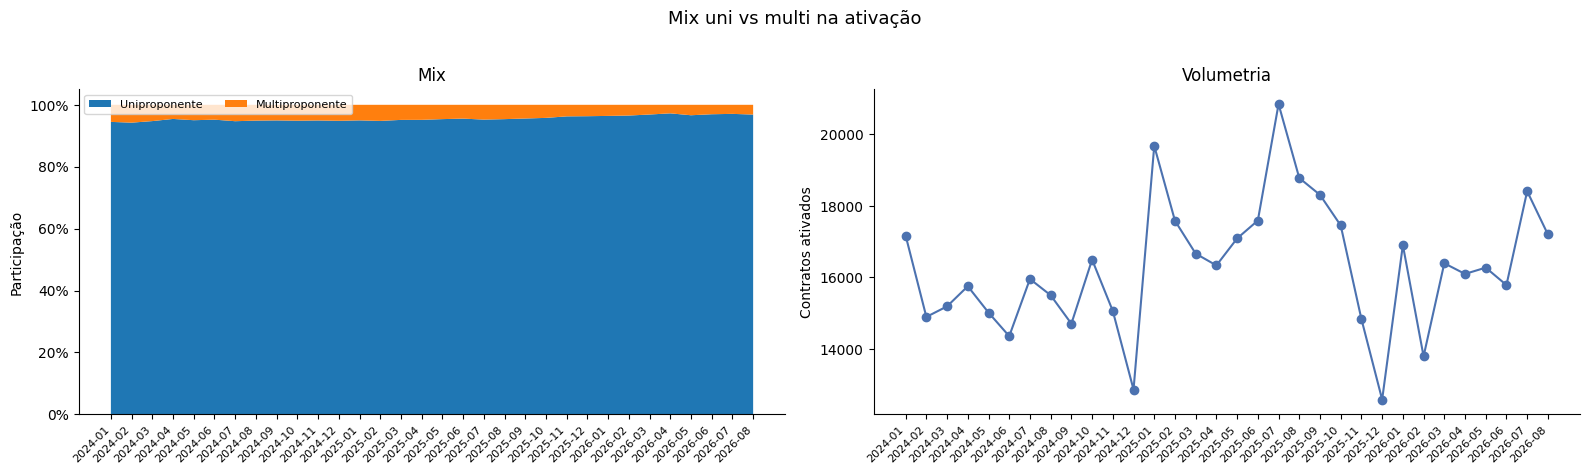

In [358]:
def plot_mix(df: pd.DataFrame, col: str, title: str, order=None) -> None:
    counts = pd.crosstab(df["safra_ativacao"], df[col], dropna=False)
    if order:
        cols = [c for c in order if c in counts.columns]
        cols += [c for c in counts.columns if c not in cols]
        counts = counts[cols]
    share = counts.div(counts.sum(axis=1), axis=0)
    x = np.arange(len(share))
    fig, axes = plt.subplots(1, 2, figsize=(16, 4.6))

    axes[0].stackplot(x, *[share[c].to_numpy() for c in share.columns], labels=share.columns)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(share.index.astype(str), rotation=45, ha="right", fontsize=8)
    axes[0].set_ylabel("Participação")
    axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
    axes[0].set_title("Mix")
    axes[0].legend(loc="upper left", fontsize=8, ncol=2)
    axes[0].spines["top"].set_visible(False)
    axes[0].spines["right"].set_visible(False)

    axes[1].plot(x, counts.sum(axis=1).to_numpy(), marker="o", color="#4C72B0")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(share.index.astype(str), rotation=45, ha="right", fontsize=8)
    axes[1].set_ylabel("Contratos ativados")
    axes[1].set_title("Volumetria")
    axes[1].spines["top"].set_visible(False)
    axes[1].spines["right"].set_visible(False)

    fig.suptitle(title, fontsize=13, y=1.02)
    fig.tight_layout()
    plt.show()


plot_mix(
    df_ctr.assign(modelo=df_ctr["bureau_nm_ajust"].fillna("Outros")),
    "modelo",
    "Mix de modelo na ativação",
    order=["BLEND2", "BLEND3", "BLEND4", "Outros"],
)
plot_mix(
    df_ctr.assign(fallback=np.where(df_ctr["is_fallback"] == 1, "Fallback", "Principal")),
    "fallback",
    "Mix de fallback na ativação",
    order=["Principal", "Fallback"],
)
plot_mix(
    df_ctr.assign(
        proponente=np.where(df_ctr["is_single_proponent"] == 1, "Uniproponente", "Multiproponente")
    ),
    "proponente",
    "Mix uni vs multi na ativação",
    order=["Uniproponente", "Multiproponente"],
)

## Outras leituras úteis

Além dos cortes 1–5, o que mais costuma explicar movimento de PC/PCC/PD:

- **Mix (já acima):** se a taxa geral sobe e o mix de Blend2/fallback/multi também sobe, o modelo pode estar estável.
- **Uni vs multi no mesmo gráfico:** o multi costuma ter taxa e maturação diferentes; vale olhar 3m e 6m lado a lado.
- **`rating_score_ds`:** inadimplência por faixa de rating, por modelo. Detecta piora de originação dentro do mesmo blend.
- **`product_nm` / `agency_segmentacao`:** Fit vs Smart vs Smart Plus, e imobiliária, mudam o risco sem o score ter degradado.
- **Cidade / UF:** se o Blend4 concentra em praças piores, a taxa do modelo sobe por mix geográfico.
- **`time2def_pc` / `time2def_pcc` / `time2def_pd`:** a taxa da janela pode estar estável enquanto o default chega mais cedo.
- **Cobertura de maturidade:** a tabela abaixo de cada gráfico quantifica `n_maturados / n_ativados` nas safras incompletas (barras hachuradas). Não ler queda de taxa nessas safras como melhoria.
- **Fallback sozinho:** taxa do `is_fallback = 1` vs principal, por modelo — o bureau de contingência pode estar piorando o resultado agregado.

## Extra: uniproponente vs multiproponente (mesmo gráfico)

Janelas 3m e 6m, um gráfico abaixo do outro. Linhas sólidas = uni, tracejadas = multi.

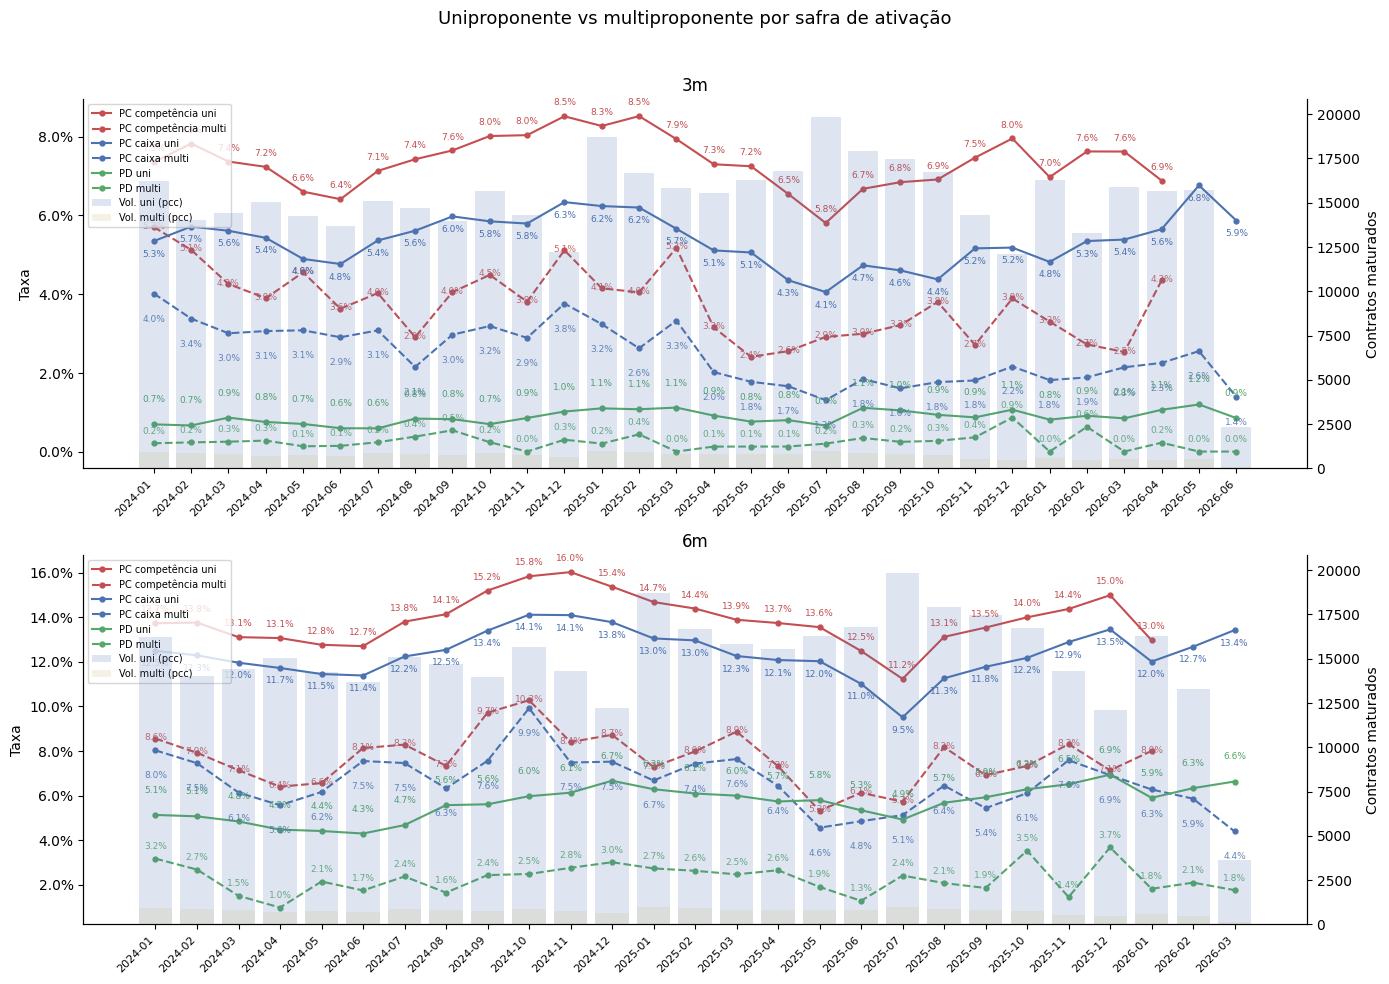

Público maturado (safras incompletas) — 3m


modelo,safra,n_ativados,n_maturados,pct_maturado
uniproponente,2026-06,"15,305","2,352",15.4%
multiproponente,2026-06,481,72,15.0%


Público maturado (safras incompletas) — 6m


modelo,safra,n_ativados,n_maturados,pct_maturado
uniproponente,2026-03,"15,881","3,651",23.0%
multiproponente,2026-03,514,114,22.2%


In [359]:
def plot_uni_vs_multi(df: pd.DataFrame, windows=(3, 6)) -> None:
    df_uni = df[df["is_single_proponent"] == 1]
    df_multi = df[df["is_single_proponent"] == 0]
    fig, axes = plt.subplots(len(windows), 1, figsize=(14, 4.8 * len(windows)), squeeze=False)
    coverage_by_window = []
    for ax, window in zip(axes[:, 0], windows):
        perf_uni = cohort_window(df_uni, window)
        perf_multi = cohort_window(df_multi, window)
        coverage_by_window.append(
            (
                window,
                pd.concat(
                    [
                        incomplete_vintages(perf_uni, model="uniproponente"),
                        incomplete_vintages(perf_multi, model="multiproponente"),
                    ],
                    ignore_index=True,
                ),
            )
        )
        idx = perf_uni.index.union(perf_multi.index)
        perf_uni = perf_uni.reindex(idx)
        perf_multi = perf_multi.reindex(idx)
        x = np.arange(len(idx))
        ax_vol = ax.twinx()
        ax_vol.bar(x, perf_uni["n_matured"].fillna(0), alpha=0.18, color="#4C72B0", label="Vol. uni (pcc)")
        ax_vol.bar(x, perf_multi["n_matured"].fillna(0), alpha=0.18, color="#CCB974", label="Vol. multi (pcc)")
        ax_vol.set_ylabel("Contratos maturados")
        offsets = {"pc": 8, "pcc": -11, "pd": 16}
        for metric, color in METRIC_COLORS.items():
            ax.plot(x, perf_uni[metric], marker="o", markersize=3.5, color=color, label=f"{METRIC_LABELS[metric]} uni")
            ax.plot(
                x,
                perf_multi[metric],
                marker="o",
                markersize=3.5,
                color=color,
                linestyle="--",
                label=f"{METRIC_LABELS[metric]} multi",
            )
            for xi, yi in zip(x, perf_uni[metric]):
                if pd.isna(yi):
                    continue
                ax.annotate(
                    f"{yi:.1%}",
                    (xi, yi),
                    textcoords="offset points",
                    xytext=(0, offsets[metric]),
                    ha="center",
                    fontsize=6.5,
                    color=color,
                )
            for xi, yi in zip(x, perf_multi[metric]):
                if pd.isna(yi):
                    continue
                ax.annotate(
                    f"{yi:.1%}",
                    (xi, yi),
                    textcoords="offset points",
                    xytext=(0, offsets[metric] - 9),
                    ha="center",
                    fontsize=6.5,
                    color=color,
                    alpha=0.85,
                )
        ax.set_xticks(x)
        ax.set_xticklabels(idx.astype(str), rotation=45, ha="right", fontsize=8)
        ax.set_ylabel("Taxa")
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.1%}"))
        ax.set_title(f"{window}m")
        ax.spines["top"].set_visible(False)
        ax_vol.spines["top"].set_visible(False)
        handles, labels_h = ax.get_legend_handles_labels()
        handles_v, labels_v = ax_vol.get_legend_handles_labels()
        ax.legend(handles + handles_v, labels_h + labels_v, loc="upper left", fontsize=7)
    fig.suptitle("Uniproponente vs multiproponente por safra de ativação", fontsize=13, y=1.02)
    fig.tight_layout()
    plt.show()
    for window, table in coverage_by_window:
        show_maturity_coverage(table, window)


plot_uni_vs_multi(df_ctr)